# HF 34C notochord loss by phenotype

This notebook estimates notochord cell-type loss in non-normal embryos relative to normal embryos using the original HF v2.2.0 projected CDS and the phenotype labels in `mmc2.csv`.

Working assumptions to revisit later:

- `mmc2.csv` is the label table.
- `pheno_note == "norm"` means normal; anything else is treated as non-normal.
- The current label table has 34C normal/severe embryos at 24, 30, and 36 hpf.
- The primary abundance metric is cells per 1,000 total recovered cells in that embryo.
- Suspected notochord doublets are dropped.
- The notebook reads `cds_object.rds` by default because only `colData` is needed. Set `load_full_cds <- TRUE` if you specifically need the BPCells-backed CDS object loaded via `load_monocle_objects()`.

In [1]:
hdf5_lib <- "/net/gs/vol3/software/modules-sw/hdf5/1.14.3/Linux/Ubuntu22.04/x86_64/lib/libhdf5.so.310"

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(stringr)
  library(purrr)
})

theme_set(theme_bw(base_size = 22))
options(dplyr.summarise.inform = FALSE)


In [2]:
hf_cds_path <- "/net/seahub_zfish/vol1/data/annotated/v2.2.0/HF/HF_projected_cds_v2.2.0/"
temp_path <- "/net/trapnell/vol1/home/elizab9/tmp_files/nobackup/"
label_path <- "/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260615/mmc2.csv"

out_dir <- "/net/trapnell/vol1/home/nlammers/projects/data/morphseq/results/nlammers/20260615/hf_34c_notochord_loss"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

analysis_temp <- "34C"
load_full_cds <- FALSE
force_recount <- FALSE

count_cache_path <- file.path(out_dir, "hf_embryo_notochord_counts.rds")
embryo_table_path <- file.path(out_dir, "hf_34c_notochord_embryo_counts_by_pheno.csv")
loss_summary_path <- file.path(out_dir, "hf_34c_notochord_fractional_loss_summary.csv")
join_diagnostics_path <- file.path(out_dir, "hf_34c_label_join_diagnostics.csv")
total_cells_plot_table_path <- file.path(out_dir, "hf_34c_total_cells_per_embryo_by_timepoint.csv")
nb_model_results_path <- file.path(out_dir, "hf_34c_notochord_nb_model_results.csv")

# Plot canvases are scaled by area; dimensions use sqrt(area multiplier).
plot_area_multiplier <- 2
plot_dimension_scale <- sqrt(plot_area_multiplier)

# Final bar plot fill convention: solid fill only for significant NB contrasts.
nb_significance_alpha <- 0.05
bar_significance_column <- "p_value"  # use "bh_q_value" for BH-adjusted significance
solid_fill_requires_non_sparse <- TRUE


## Phenotype labels

The CDS stores embryo IDs as compact values such as `HF4_P02_C2`. The label table stores longer names such as `HF4-24-HF4-24hpf-34C_P2_C2`, so this cell derives the compact CDS embryo ID from the plate and well suffix.

In [3]:
normalize_label_table <- function(path) {
  labels_raw <- read.csv(path, stringsAsFactors = FALSE)

  required_cols <- c("timepoint", "temp", "embryo", "well", "pheno_note")
  missing_cols <- setdiff(required_cols, colnames(labels_raw))
  if (length(missing_cols) > 0) {
    stop("Label table is missing required columns: ", paste(missing_cols, collapse = ", "))
  }

  plate_match <- str_match(labels_raw$embryo, "_P([0-9]+)_([A-H][0-9]+)$")

  labels_raw %>%
    mutate(
      hpf = as.numeric(timepoint),
      temp = as.character(temp),
      pheno_note = str_to_lower(str_trim(as.character(pheno_note))),
      plate = as.integer(plate_match[, 2]),
      well_from_embryo = plate_match[, 3],
      well = coalesce(well_from_embryo, as.character(well)),
      embryo_ID = sprintf("HF4_P%02d_%s", plate, well),
      phenotype_group = if_else(pheno_note %in% c("norm", "normal"), "normal", "non_normal"),
      phenotype_label = recode(phenotype_group, normal = "normal", non_normal = "non-normal"),
      phenotype_detail = pheno_note
    ) %>%
    dplyr::select(timepoint, hpf, temp, embryo, embryo_ID, well, pheno_note, phenotype_group, phenotype_label, phenotype_detail, tag, everything())
}

labels <- normalize_label_table(label_path)
labels_34 <- labels %>% filter(temp == analysis_temp)

labels %>%
  count(hpf, temp, phenotype_detail, phenotype_group) %>%
  arrange(hpf, temp, phenotype_detail)

hpf,temp,phenotype_detail,phenotype_group,n
<dbl>,<chr>,<chr>,<chr>,<int>
24,28C,norm,normal,16
24,32C,norm,normal,24
24,32C,severe,non_normal,16
24,34C,norm,normal,20
24,34C,severe,non_normal,20
30,28C,norm,normal,16
30,32C,norm,normal,20
30,32C,severe,non_normal,20
30,34C,norm,normal,20


In [22]:
nrow(labels_34) / 3

[1] 40

In [4]:
labels_34 %>%
  count(hpf, phenotype_label, phenotype_detail) %>%
  arrange(hpf, phenotype_label, phenotype_detail)

hpf,phenotype_label,phenotype_detail,n
<dbl>,<chr>,<chr>,<int>
24,non-normal,severe,20
24,normal,norm,20
30,non-normal,severe,20
30,normal,norm,20
36,non-normal,severe,20
36,normal,norm,20


## Load HF metadata

By default this reads the serialized CDS object and extracts `colData` directly. This avoids loading the BPCells expression matrix because the analysis only needs cell metadata. To use the full object loader, set `load_full_cds <- TRUE` above.

In [5]:
extract_cds_coldata <- function(cds) {
  cd <- attr(cds, "colData")
  ld <- attr(cd, "listData")
  rn <- attr(cd, "rownames")

  if (!is.null(ld) && length(ld) > 0) {
    out <- as.data.frame(ld, check.names = FALSE, stringsAsFactors = FALSE)
    out <- as_tibble(out)
    if (!is.null(rn) && length(rn) == nrow(out)) {
      out <- out %>% mutate(cell_barcode = rn, .before = 1)
    } else if ("cell" %in% colnames(out)) {
      out <- out %>% rename(cell_barcode = cell)
    }
    return(out)
  }

  out <- as.data.frame(colData(cds), stringsAsFactors = FALSE)
  rownames_to_column(as_tibble(out), "cell_barcode")
}

parse_hpf <- function(x) {
  if (is.numeric(x)) return(as.numeric(x))
  as.numeric(str_extract(as.character(x), "[0-9]+\\.?[0-9]*"))
}

if (load_full_cds) {
  if (file.exists(hdf5_lib)) dyn.load(hdf5_lib)
  suppressPackageStartupMessages({
    library(monocle3)
    library(BPCells)
    library(hooke)
  })

  HF_cds <- load_monocle_objects(
    hf_cds_path,
    matrix_control = list(matrix_class = "BPCells", matrix_path = temp_path)
  )
} else {
  HF_cds <- readRDS(file.path(hf_cds_path, "cds_object.rds"))
}


hf_md <- extract_cds_coldata(HF_cds) %>%
  mutate(
    embryo_ID = as.character(embryo_ID),
    hpf = parse_hpf(timepoint),
    cds_temp = as.character(temp),
    cell_type = as.character(cell_type)
  )

hf_md %>%
  summarise(
    n_cells = n(),
    n_embryos = n_distinct(embryo_ID),
    hpf_values = paste(sort(unique(hpf)), collapse = ", "),
    temp_values = paste(sort(unique(cds_temp)), collapse = ", ")
  )

n_cells,n_embryos,hpf_values,temp_values
<int>,<int>,<chr>,<chr>
345586,240,"24, 30, 36","32, 34"


## Harmonize HF notochord labels

These mappings are the v2-style equivalent of the atlas-comparison grouping we used previously. Edit this small table if you want a different interpretation.

In [6]:
notochord_key <- tribble(
  ~cell_type, ~standardized_cell_group,
  "early notochord", "notochordal cell",
  "early notochord progenitor", "notochordal cell",
  "early notochord sheath", "notochordal sheath cell",
  "late notochord sheath", "notochordal sheath cell",
  "late notochord sheath (entpd5a+)", "notochordal sheath cell",
  "late notochord sheath, proliferative", "notochordal sheath cell",
  "early vacuolated notochord", "notochordal vacuole cell",
  "late vacuolated notochord", "notochordal vacuole cell",
  "hypochord", "hypochord",
  "unknown 1 (notochord, suspected doublets)", NA_character_
)

notochord_candidates <- hf_md %>%
  distinct(cell_type) %>%
  filter(str_detect(cell_type, regex("notochord|hypochord", ignore_case = TRUE))) %>%
  arrange(cell_type) %>%
  left_join(notochord_key, by = "cell_type") %>%
  mutate(status = case_when(
    is.na(standardized_cell_group) & cell_type %in% notochord_key$cell_type ~ "dropped by key",
    is.na(standardized_cell_group) ~ "unmapped",
    TRUE ~ "mapped"
  ))

notochord_candidates

cell_type,standardized_cell_group,status
<chr>,<chr>,<chr>
early notochord,notochordal cell,mapped
early notochord progenitor,notochordal cell,mapped
early notochord sheath,notochordal sheath cell,mapped
early vacuolated notochord,notochordal vacuole cell,mapped
hypochord,hypochord,mapped
late notochord sheath,notochordal sheath cell,mapped
late notochord sheath (entpd5a+),notochordal sheath cell,mapped
"late notochord sheath, proliferative",notochordal sheath cell,mapped
late vacuolated notochord,notochordal vacuole cell,mapped


In [7]:
unmapped_notochord <- notochord_candidates %>% filter(status == "unmapped")
if (nrow(unmapped_notochord) > 0) {
  warning("There are notochord/hypochord-looking cell types not covered by notochord_key. They will be dropped unless you add mappings.")
}

## Count cells per embryo

This creates an embryo-level count table and caches it. It includes zeros for mapped notochord groups absent from a given embryo, which is important for estimating loss.

In [8]:
make_hf_notochord_counts <- function(hf_md, labels_34, notochord_key) {
  mapped_groups <- notochord_key %>%
    filter(!is.na(standardized_cell_group)) %>%
    distinct(standardized_cell_group) %>%
    arrange(standardized_cell_group)

  embryo_totals <- hf_md %>%
    group_by(embryo_ID) %>%
    summarise(
      total_cells = n(),
      cds_hpf = median(hpf, na.rm = TRUE),
      cds_temp = paste(sort(unique(cds_temp)), collapse = ";"),
      .groups = "drop"
    )

  notochord_counts <- hf_md %>%
    left_join(notochord_key, by = "cell_type") %>%
    filter(!is.na(standardized_cell_group)) %>%
    count(embryo_ID, standardized_cell_group, name = "cell_count")

  label_base <- labels_34 %>%
    dplyr::select(
      label_timepoint = timepoint,
      hpf,
      label_temp = temp,
      embryo,
      embryo_ID,
      well,
      phenotype_group,
      phenotype_label,
      phenotype_detail,
      tag
    ) %>%
    left_join(embryo_totals, by = "embryo_ID")

  join_diagnostics <- label_base %>%
    mutate(
      matched_cds = !is.na(total_cells),
      hpf_match = matched_cds & as.numeric(hpf) == as.numeric(cds_hpf),
      temp_match = matched_cds & str_detect(cds_temp, fixed(str_remove(label_temp, "C")))
    )

  per_group <- label_base %>%
    filter(!is.na(total_cells)) %>%
    tidyr::crossing(mapped_groups) %>%
    left_join(notochord_counts, by = c("embryo_ID", "standardized_cell_group")) %>%
    mutate(
      cell_count = replace_na(cell_count, 0L),
      cells_per_1000_total = 1000 * cell_count / total_cells,
      group_type = "mapped cell type"
    )

  total_notochord <- per_group %>%
    group_by(
      label_timepoint, hpf, label_temp, embryo, embryo_ID, well,
      phenotype_group, phenotype_label, phenotype_detail, tag,
      total_cells, cds_hpf, cds_temp
    ) %>%
    summarise(
      standardized_cell_group = "total mapped notochord/hypochord",
      cell_count = sum(cell_count),
      cells_per_1000_total = 1000 * cell_count / first(total_cells),
      group_type = "total mapped notochord/hypochord",
      .groups = "drop"
    )

  list(
    embryo_counts = bind_rows(per_group, total_notochord) %>%
      mutate(
        hpf = as.numeric(hpf),
        timepoint_label = paste0(hpf, " hpf"),
        standardized_cell_group = factor(
          standardized_cell_group,
          levels = c(sort(mapped_groups$standardized_cell_group), "total mapped notochord/hypochord")
        ),
        phenotype_label = factor(phenotype_label, levels = c("normal", "non-normal")),
        phenotype_group = factor(phenotype_group, levels = c("normal", "non_normal"))
      ),
    join_diagnostics = join_diagnostics
  )
}

if (file.exists(count_cache_path) && !force_recount) {
  cached <- readRDS(count_cache_path)
} else {
  cached <- make_hf_notochord_counts(hf_md, labels_34, notochord_key)
  saveRDS(cached, count_cache_path)
}

embryo_counts <- cached$embryo_counts
join_diagnostics <- cached$join_diagnostics

write.csv(join_diagnostics, join_diagnostics_path, row.names = FALSE)
write.csv(embryo_counts, embryo_table_path, row.names = FALSE)

join_diagnostics %>%
  count(hpf, label_temp, phenotype_label, matched_cds, hpf_match, temp_match) %>%
  arrange(hpf, label_temp, phenotype_label, desc(matched_cds))

hpf,label_temp,phenotype_label,matched_cds,hpf_match,temp_match,n
<dbl>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>
24,34C,non-normal,TRUE,TRUE,TRUE,20
24,34C,normal,TRUE,TRUE,TRUE,20
30,34C,non-normal,TRUE,TRUE,TRUE,20
30,34C,normal,TRUE,TRUE,TRUE,20
36,34C,non-normal,TRUE,TRUE,TRUE,20
36,34C,normal,TRUE,TRUE,TRUE,20


## Total Cells Per Embryo

Quick QC plot showing total recovered cells per labeled 34C embryo across timepoints.


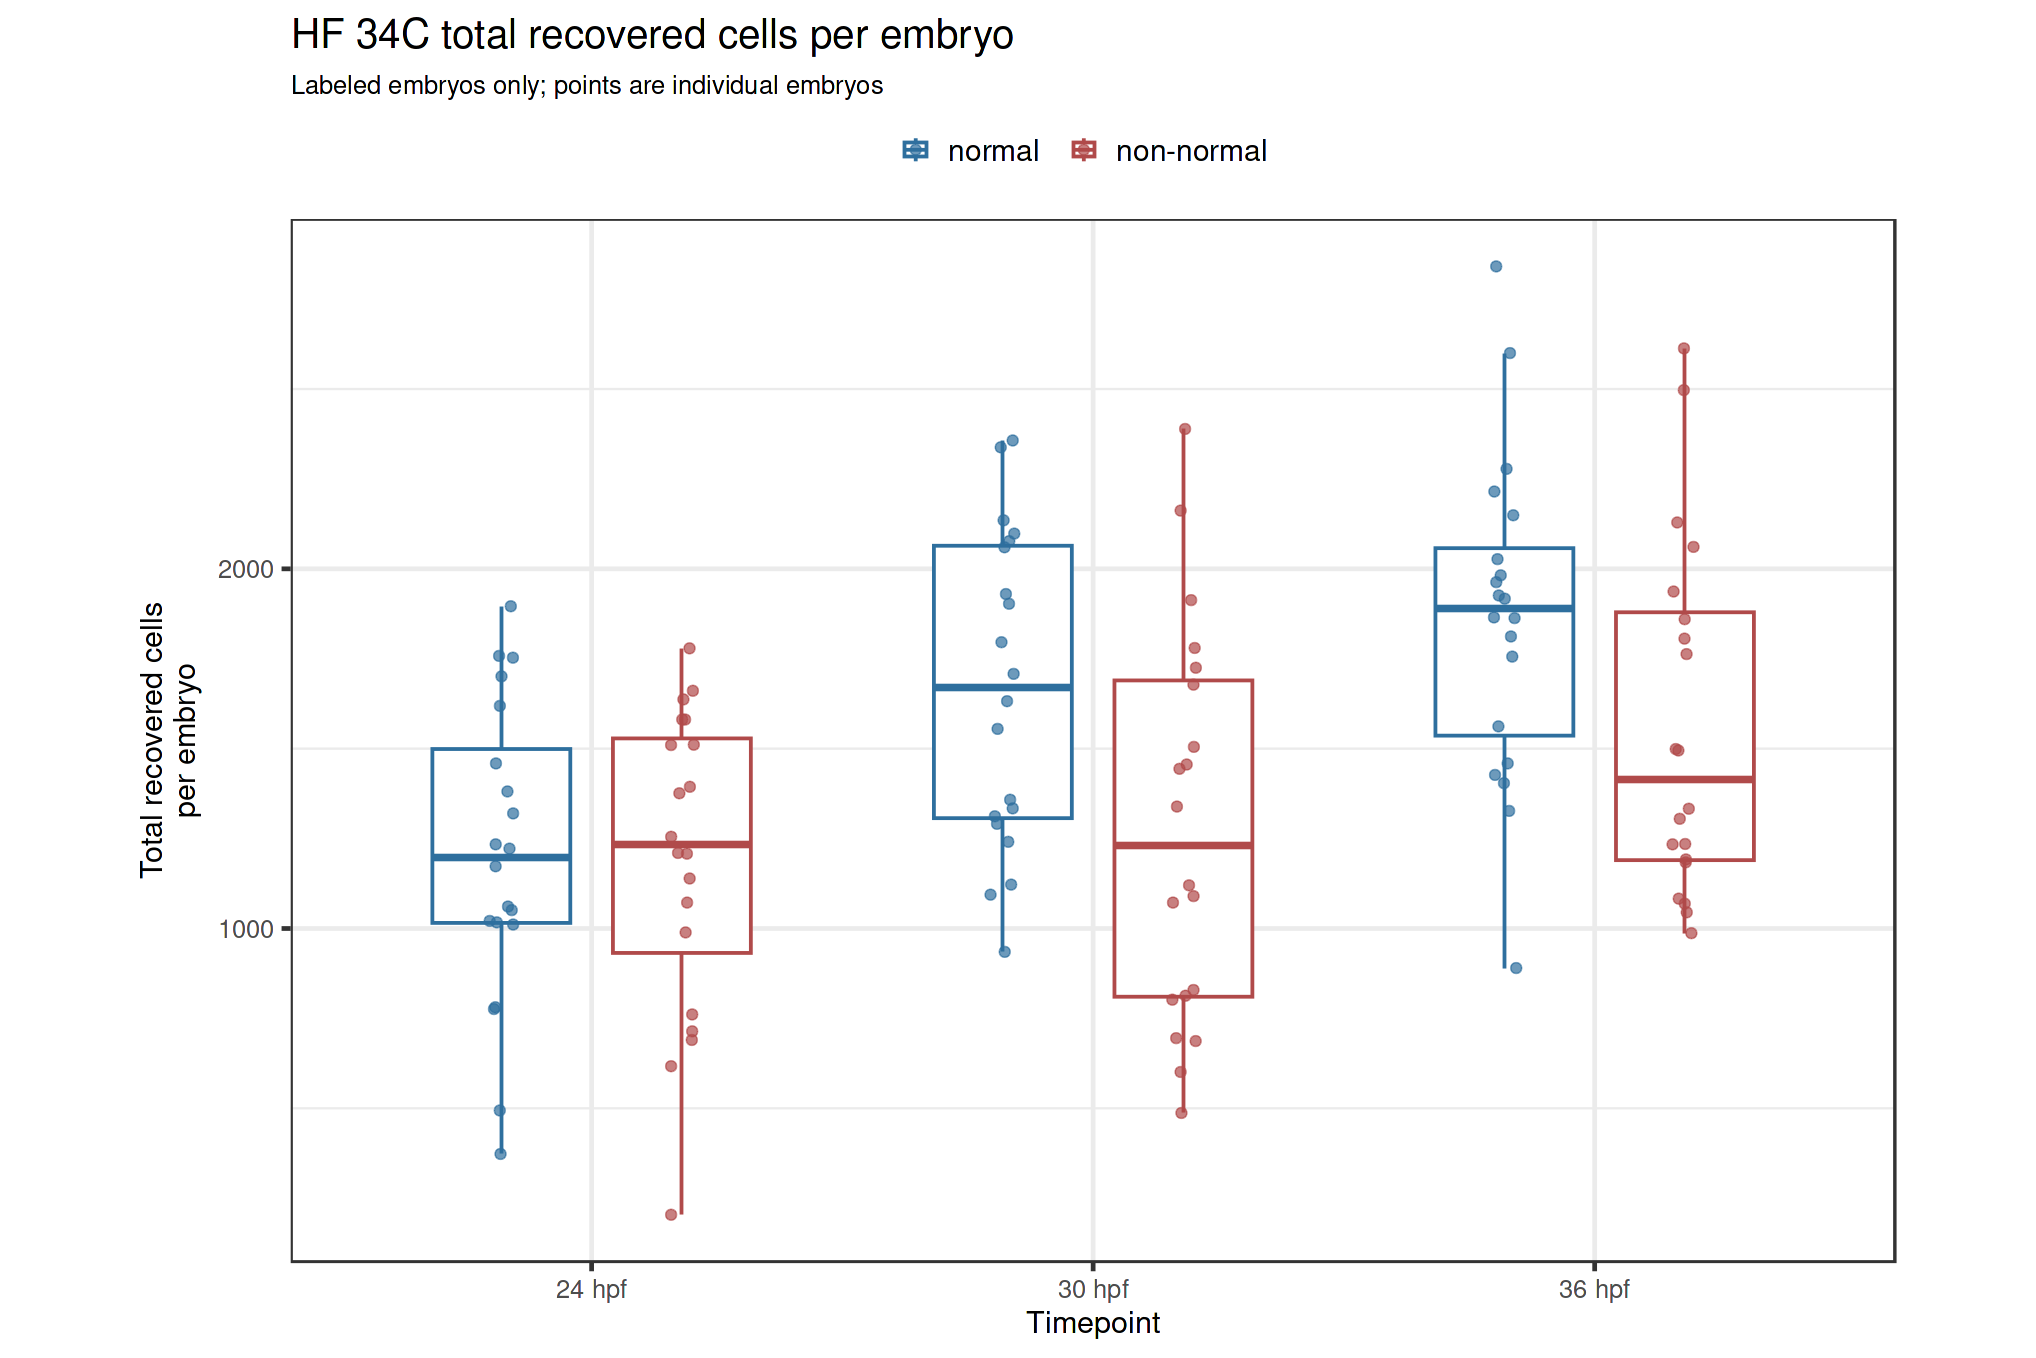

In [9]:
total_cells_plot_df <- join_diagnostics %>%
  filter(matched_cds) %>%
  distinct(embryo_ID, hpf, label_temp, phenotype_group, phenotype_label, phenotype_detail, total_cells) %>%
  mutate(
    timepoint_label = factor(paste0(hpf, " hpf"), levels = paste0(sort(unique(hpf)), " hpf")),
    phenotype_label = factor(phenotype_label, levels = c("normal", "non-normal"))
  )

write.csv(total_cells_plot_df, total_cells_plot_table_path, row.names = FALSE)

total_cells_plot_width <- 12 * plot_dimension_scale
total_cells_plot_height <- 8 * plot_dimension_scale
options(repr.plot.width = total_cells_plot_width, repr.plot.height = total_cells_plot_height)

p_total_cells <- ggplot(
  total_cells_plot_df,
  aes(x = timepoint_label, y = total_cells, color = phenotype_label)
) +
  geom_boxplot(
    aes(group = interaction(timepoint_label, phenotype_label)),
    position = position_dodge(width = 0.72),
    outlier.shape = NA,
    width = 0.55,
    linewidth = 0.8
  ) +
  geom_point(
    position = position_jitterdodge(jitter.width = 0.10, dodge.width = 0.72, seed = 4),
    size = 2.4,
    alpha = 0.70
  ) +
  scale_color_manual(values = c("normal" = "#2E6F9E", "non-normal" = "#B04A4A")) +
  labs(
    title = "HF 34C total recovered cells per embryo",
    subtitle = "Labeled embryos only; points are individual embryos",
    x = "Timepoint",
    y = "Total recovered cells\nper embryo",
    color = NULL
  ) +
  theme(
    legend.position = "top",
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 18),
    plot.title = element_text(size = 24),
    plot.subtitle = element_text(size = 15),
    aspect.ratio = 0.65
  )

p_total_cells

ggsave(file.path(out_dir, "hf_34c_total_cells_per_embryo_by_timepoint.png"), p_total_cells, width = total_cells_plot_width, height = total_cells_plot_height, dpi = 300)
ggsave(file.path(out_dir, "hf_34c_total_cells_per_embryo_by_timepoint.pdf"), p_total_cells, width = total_cells_plot_width, height = total_cells_plot_height)

In [10]:
total_cells_summary <- total_cells_plot_df %>%
  group_by(hpf, timepoint_label, phenotype_label) %>%
  summarise(
    n_embryos = n_distinct(embryo_ID),
    mean_total_cells = mean(total_cells, na.rm = TRUE),
    median_total_cells = median(total_cells, na.rm = TRUE),
    sd_total_cells = sd(total_cells, na.rm = TRUE),
    min_total_cells = min(total_cells, na.rm = TRUE),
    max_total_cells = max(total_cells, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(hpf, phenotype_label)

total_cells_summary

total_cells_plot_df %>%
  arrange(hpf, phenotype_label, embryo_ID) %>%
  dplyr::select(hpf, timepoint_label, phenotype_label, phenotype_detail, embryo_ID, total_cells)


hpf,timepoint_label,phenotype_label,n_embryos,mean_total_cells,median_total_cells,sd_total_cells,min_total_cells,max_total_cells
<dbl>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
24,24 hpf,normal,20,1205.05,1197.5,418.3128,373,1896
24,24 hpf,non-normal,20,1194.45,1232.5,421.6888,204,1779
30,30 hpf,normal,20,1663.80,1670.0,436.9061,935,2357
30,30 hpf,non-normal,20,1279.35,1229.5,546.0670,487,2389
36,36 hpf,normal,20,1863.15,1891.0,449.4554,890,2841
36,36 hpf,non-normal,20,1566.35,1414.0,490.4323,987,2613


hpf,timepoint_label,phenotype_label,phenotype_detail,embryo_ID,total_cells
<dbl>,<fct>,<fct>,<chr>,<chr>,<int>
24,24 hpf,normal,norm,HF4_P02_A10,1619
24,24 hpf,normal,norm,HF4_P02_A8,1173
24,24 hpf,normal,norm,HF4_P02_A9,373
24,24 hpf,normal,norm,HF4_P02_B10,1701
24,24 hpf,normal,norm,HF4_P02_B8,1758
24,24 hpf,normal,norm,HF4_P02_B9,776
24,24 hpf,normal,norm,HF4_P02_C10,1222
24,24 hpf,normal,norm,HF4_P02_C8,1381
24,24 hpf,normal,norm,HF4_P02_C9,1021


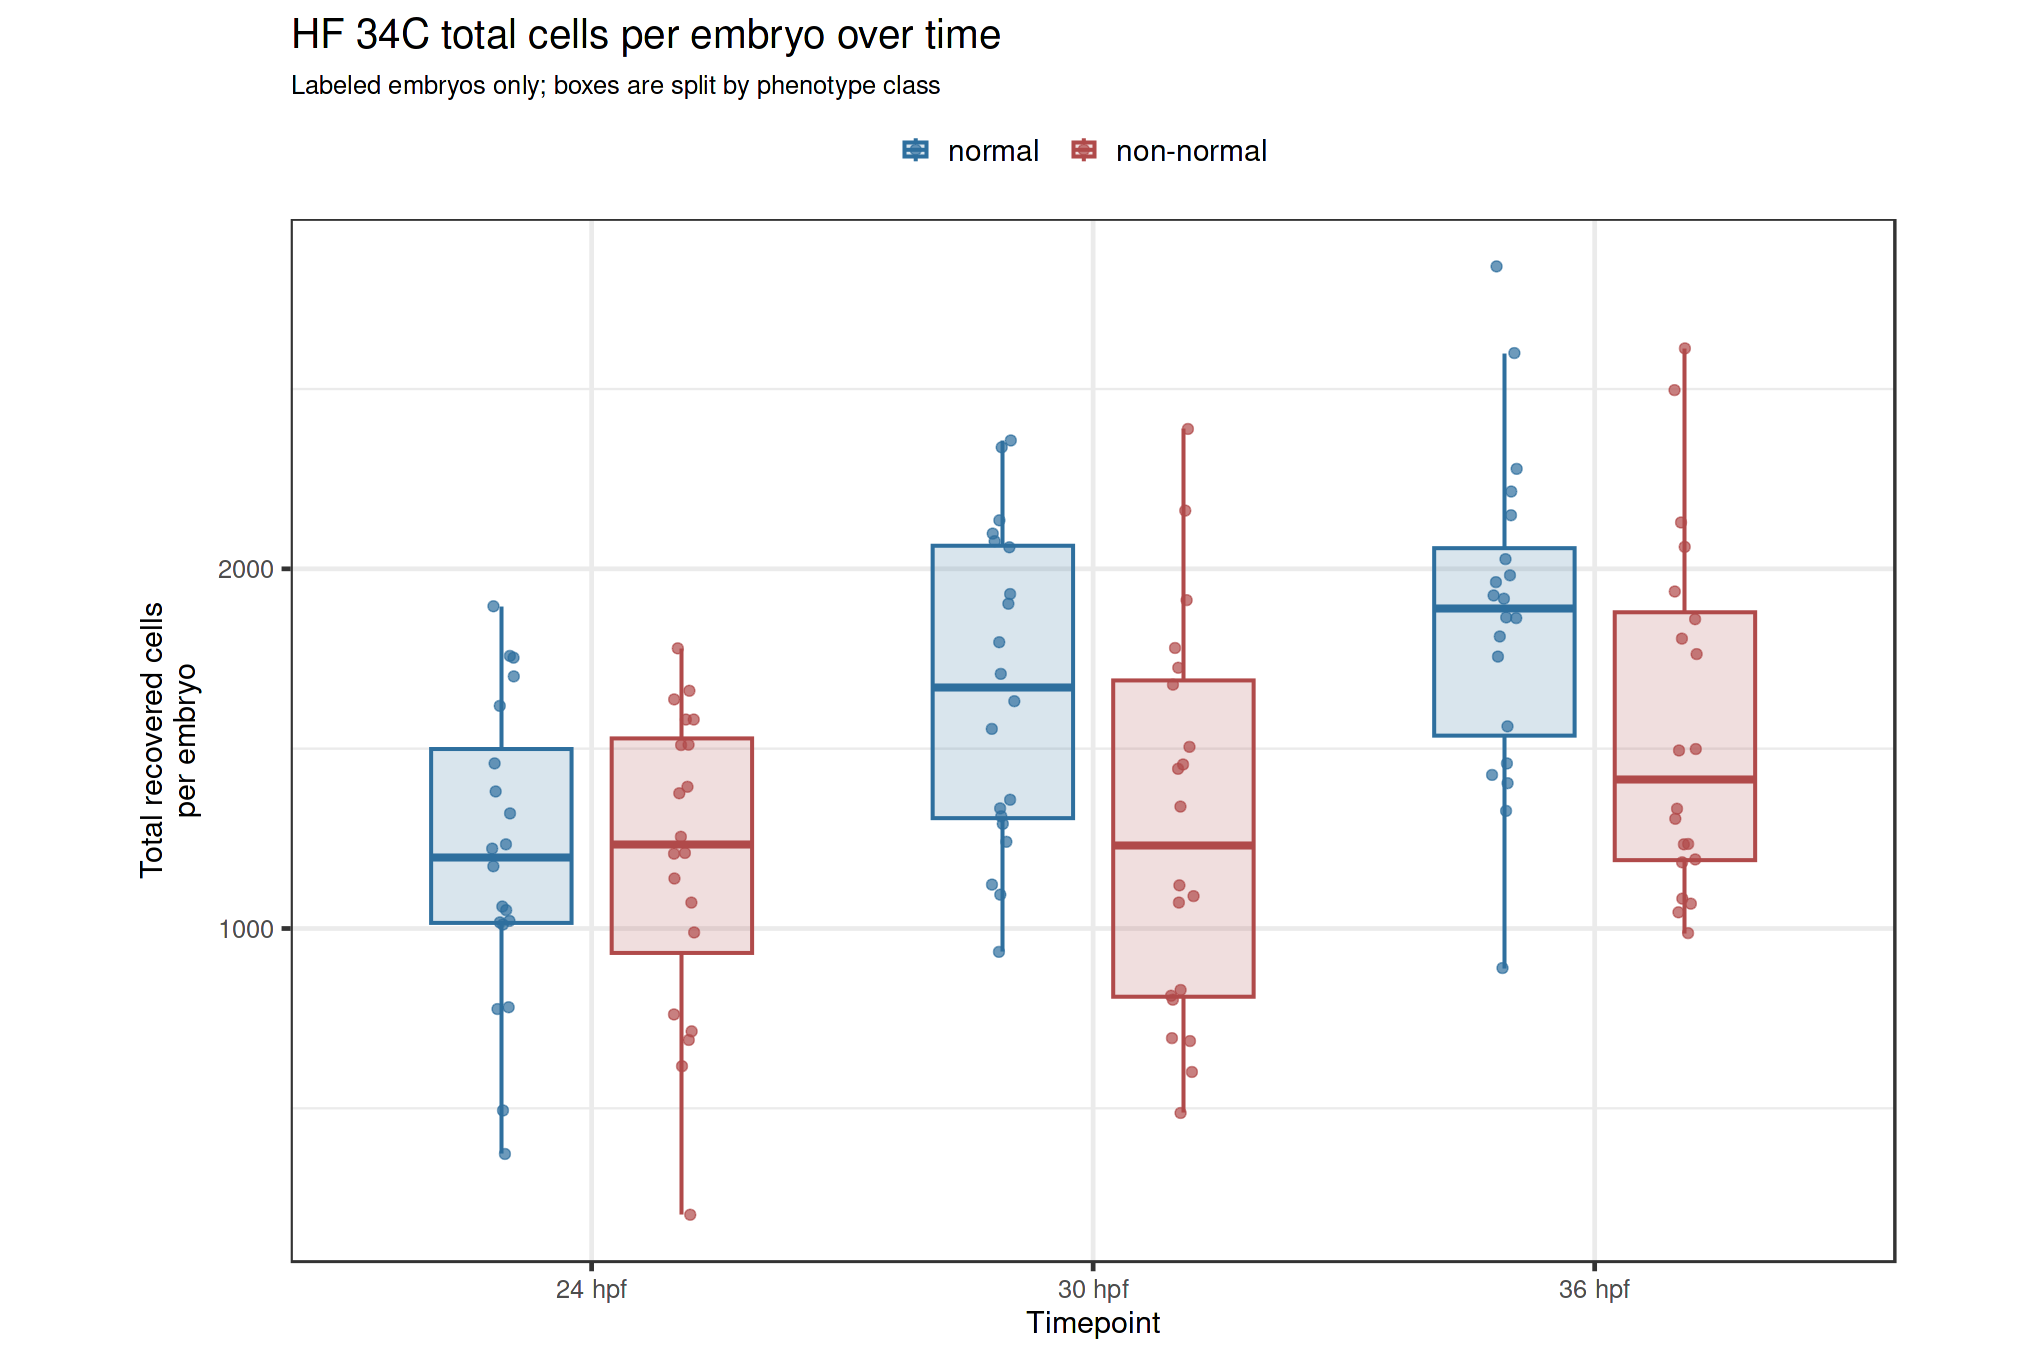

In [11]:
total_cells_box_width <- 12 * plot_dimension_scale
total_cells_box_height <- 8 * plot_dimension_scale
options(repr.plot.width = total_cells_box_width, repr.plot.height = total_cells_box_height)

p_total_cells_box <- ggplot(
  total_cells_plot_df,
  aes(x = timepoint_label, y = total_cells, color = phenotype_label, fill = phenotype_label)
) +
  geom_boxplot(
    position = position_dodge(width = 0.72),
    outlier.shape = NA,
    width = 0.56,
    linewidth = 0.85,
    alpha = 0.18
  ) +
  geom_point(
    position = position_jitterdodge(jitter.width = 0.10, dodge.width = 0.72, seed = 7),
    size = 2.4,
    alpha = 0.70
  ) +
  scale_color_manual(values = c("normal" = "#2E6F9E", "non-normal" = "#B04A4A")) +
  scale_fill_manual(values = c("normal" = "#2E6F9E", "non-normal" = "#B04A4A")) +
  labs(
    title = "HF 34C total cells per embryo over time",
    subtitle = "Labeled embryos only; boxes are split by phenotype class",
    x = "Timepoint",
    y = "Total recovered cells\nper embryo",
    color = NULL,
    fill = NULL
  ) +
  theme(
    legend.position = "top",
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 18),
    plot.title = element_text(size = 24),
    plot.subtitle = element_text(size = 15),
    aspect.ratio = 0.65
  )

p_total_cells_box

ggsave(file.path(out_dir, "hf_34c_total_cells_per_embryo_boxplot.png"), p_total_cells_box, width = total_cells_box_width, height = total_cells_box_height, dpi = 300)
ggsave(file.path(out_dir, "hf_34c_total_cells_per_embryo_boxplot.pdf"), p_total_cells_box, width = total_cells_box_width, height = total_cells_box_height)

## Fractional loss summaries

Primary loss metric: `1 - mean(non-normal cells per 1,000 total cells) / mean(normal cells per 1,000 total cells)`.

Positive values indicate depletion in non-normal embryos. Negative values indicate enrichment in non-normal embryos. Median-based and raw-count versions are included for review.

In [12]:
safe_loss <- function(non_normal, normal) {
  if_else(is.na(normal) | normal == 0, NA_real_, 1 - non_normal / normal)
}

summary_by_group <- embryo_counts %>%
  group_by(hpf, timepoint_label, standardized_cell_group, group_type, phenotype_group, phenotype_label) %>%
  summarise(
    n_embryos = n_distinct(embryo_ID),
    mean_count = mean(cell_count, na.rm = TRUE),
    median_count = median(cell_count, na.rm = TRUE),
    sd_count = sd(cell_count, na.rm = TRUE),
    se_count = sd_count / sqrt(n_embryos),
    mean_per_1000 = mean(cells_per_1000_total, na.rm = TRUE),
    median_per_1000 = median(cells_per_1000_total, na.rm = TRUE),
    sd_per_1000 = sd(cells_per_1000_total, na.rm = TRUE),
    se_per_1000 = sd_per_1000 / sqrt(n_embryos),
    .groups = "drop"
  )

loss_summary <- summary_by_group %>%
  dplyr::select(-phenotype_label) %>%
  pivot_wider(
    names_from = phenotype_group,
    values_from = c(n_embryos, mean_count, median_count, sd_count, se_count, mean_per_1000, median_per_1000, sd_per_1000, se_per_1000)
  ) %>%
  mutate(
    fractional_loss_mean_per_1000 = safe_loss(mean_per_1000_non_normal, mean_per_1000_normal),
    fractional_loss_median_per_1000 = safe_loss(median_per_1000_non_normal, median_per_1000_normal),
    fractional_loss_mean_raw_count = safe_loss(mean_count_non_normal, mean_count_normal),
    fractional_loss_median_raw_count = safe_loss(median_count_non_normal, median_count_normal)
  ) %>%
  arrange(hpf, standardized_cell_group)

write.csv(loss_summary, loss_summary_path, row.names = FALSE)

loss_summary

hpf,timepoint_label,standardized_cell_group,group_type,n_embryos_normal,n_embryos_non_normal,mean_count_normal,mean_count_non_normal,median_count_normal,median_count_non_normal,⋯,median_per_1000_normal,median_per_1000_non_normal,sd_per_1000_normal,sd_per_1000_non_normal,se_per_1000_normal,se_per_1000_non_normal,fractional_loss_mean_per_1000,fractional_loss_median_per_1000,fractional_loss_mean_raw_count,fractional_loss_median_raw_count
<dbl>,<chr>,<fct>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
24,24 hpf,hypochord,mapped cell type,20,20,0.10,0.10,0.0,0.0,⋯,0.0000000,0.0000000,0.2378686,0.2626397,0.05318904,0.05872802,-0.10589310,NA,0.0000000,NA
24,24 hpf,notochordal cell,mapped cell type,20,20,0.00,0.10,0.0,0.0,⋯,0.0000000,0.0000000,0.0000000,0.2961679,0.00000000,0.06622517,NA,NA,NA,NA
24,24 hpf,notochordal sheath cell,mapped cell type,20,20,7.55,5.35,3.0,2.0,⋯,2.6192550,1.2239269,6.9328510,6.4784361,1.55023262,1.44862236,0.18034660,0.53271944,0.2913907,0.3333333
24,24 hpf,notochordal vacuole cell,mapped cell type,20,20,0.50,0.20,0.0,0.0,⋯,0.0000000,0.0000000,0.5842088,0.4246923,0.13063307,0.09496409,0.51538047,NA,0.6000000,NA
24,24 hpf,total mapped notochord/hypochord,total mapped notochord/hypochord,20,20,8.15,5.75,3.0,2.0,⋯,2.8963601,1.2239269,7.2194087,6.8117535,1.61430886,1.52315440,0.18438036,0.57742584,0.2944785,0.3333333
30,30 hpf,hypochord,mapped cell type,20,20,0.30,0.20,0.0,0.0,⋯,0.0000000,0.0000000,0.3138678,0.4308266,0.07018298,0.09633576,0.05513444,NA,0.3333333,NA
30,30 hpf,notochordal cell,mapped cell type,20,20,0.05,0.00,0.0,0.0,⋯,0.0000000,0.0000000,0.1437986,0.0000000,0.03215434,0.00000000,1.00000000,NA,1.0000000,NA
30,30 hpf,notochordal sheath cell,mapped cell type,20,20,17.20,9.65,15.0,7.5,⋯,6.7357929,3.7601572,8.0647163,6.1710842,1.80332540,1.37989637,0.33722366,0.44176473,0.4389535,0.5000000
30,30 hpf,notochordal vacuole cell,mapped cell type,20,20,1.20,0.50,1.0,0.0,⋯,0.4565764,0.0000000,1.0194310,0.6191165,0.22795170,0.13843866,0.54932438,1.00000000,0.5833333,1.0000000


In [13]:
summary_by_group %>%
  arrange(hpf, standardized_cell_group, phenotype_group)

hpf,timepoint_label,standardized_cell_group,group_type,phenotype_group,phenotype_label,n_embryos,mean_count,median_count,sd_count,se_count,mean_per_1000,median_per_1000,sd_per_1000,se_per_1000
<dbl>,<chr>,<fct>,<chr>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
24,24 hpf,hypochord,mapped cell type,normal,normal,20,0.10,0.0,0.3077935,0.06882472,0.07712218,0.0000000,0.2378686,0.05318904
24,24 hpf,hypochord,mapped cell type,non_normal,non-normal,20,0.10,0.0,0.3077935,0.06882472,0.08528888,0.0000000,0.2626397,0.05872802
24,24 hpf,notochordal cell,mapped cell type,normal,normal,20,0.00,0.0,0.0000000,0.00000000,0.00000000,0.0000000,0.0000000,0.00000000
24,24 hpf,notochordal cell,mapped cell type,non_normal,non-normal,20,0.10,0.0,0.4472136,0.10000000,0.06622517,0.0000000,0.2961679,0.06622517
24,24 hpf,notochordal sheath cell,mapped cell type,normal,normal,20,7.55,3.0,11.5689011,2.58688494,5.11945471,2.6192550,6.9328510,1.55023262
24,24 hpf,notochordal sheath cell,mapped cell type,non_normal,non-normal,20,5.35,2.0,8.4496964,1.88940954,4.19617848,1.2239269,6.4784361,1.44862236
24,24 hpf,notochordal vacuole cell,mapped cell type,normal,normal,20,0.50,0.0,1.0000000,0.22360680,0.33009767,0.0000000,0.5842088,0.13063307
24,24 hpf,notochordal vacuole cell,mapped cell type,non_normal,non-normal,20,0.20,0.0,0.5231484,0.11697953,0.15997178,0.0000000,0.4246923,0.09496409
24,24 hpf,total mapped notochord/hypochord,total mapped notochord/hypochord,normal,normal,20,8.15,3.0,12.2142066,2.73117962,5.52667456,2.8963601,7.2194087,1.61430886


## Negative binomial phenotype model

This is the same inference model family used in the power simulations: per-cell-type negative binomial GLM on embryo counts with an offset for total recovered cells. Here `non_normal` replaces simulated `MT`, and `normal` replaces simulated `WT`. With multiple timepoints, one model is fit per cell group using a phenotype-by-timepoint interaction, then the non-normal-vs-normal contrast is extracted for each timepoint.


In [14]:
suppressPackageStartupMessages(library(MASS))

if (!exists("nb_model_results_path")) {
  nb_model_results_path <- file.path(out_dir, "hf_34c_notochord_nb_model_results.csv")
}

extract_phenotype_timepoint_effects <- function(fit, timepoint_levels, timepoint_col = "timepoint_factor") {
  coefs <- stats::coef(fit)
  vcov_m <- stats::vcov(fit)
  base_term <- "phenotype_groupnon_normal"

  bind_rows(lapply(timepoint_levels, function(tp) {
    int_term <- intersect(
      c(
        paste0(base_term, ":", timepoint_col, tp),
        paste0(timepoint_col, tp, ":", base_term)
      ),
      names(coefs)
    )
    terms_used <- c(base_term, int_term)

    if (!all(terms_used %in% names(coefs))) {
      return(tibble(
        timepoint = tp,
        estimated_effect = NA_real_,
        std_error = NA_real_,
        wald_z = NA_real_,
        wald_p_value = NA_real_,
        p_value = NA_real_
      ))
    }

    est <- sum(coefs[terms_used])
    se <- sqrt(sum(vcov_m[terms_used, terms_used]))
    z <- est / se
    wald_p <- 2 * stats::pnorm(abs(z), lower.tail = FALSE)

    tibble(
      timepoint = tp,
      estimated_effect = unname(est),
      std_error = unname(se),
      wald_z = unname(z),
      wald_p_value = unname(wald_p),
      p_value = unname(wald_p)
    )
  }))
}

fit_nb_one_cell_group <- function(df, timepoint_levels) {
  if (length(unique(df$phenotype_group)) < 2 || length(unique(df$timepoint_factor)) < 1) {
    return(expand_grid(timepoint = timepoint_levels) %>%
      mutate(
        estimated_effect = NA_real_,
        std_error = NA_real_,
        wald_z = NA_real_,
        wald_p_value = NA_real_,
        p_value = NA_real_,
        model_converged = FALSE,
        model_note = "insufficient phenotype or timepoint levels"
      ))
  }

  fml <- if (length(timepoint_levels) == 1) {
    count ~ phenotype_group + offset(log_total)
  } else {
    count ~ phenotype_group * timepoint_factor + offset(log_total)
  }

  fit <- tryCatch(
    suppressWarnings(MASS::glm.nb(fml, data = df)),
    error = function(e) NULL
  )

  if (is.null(fit)) {
    return(expand_grid(timepoint = timepoint_levels) %>%
      mutate(
        estimated_effect = NA_real_,
        std_error = NA_real_,
        wald_z = NA_real_,
        wald_p_value = NA_real_,
        p_value = NA_real_,
        model_converged = FALSE,
        model_note = "glm.nb failed"
      ))
  }

  extract_phenotype_timepoint_effects(fit, timepoint_levels) %>%
    mutate(model_converged = TRUE, model_note = NA_character_)
}

nb_model_data <- embryo_counts %>%
  mutate(
    count = as.numeric(cell_count),
    log_total = log(pmax(total_cells, 1)),
    phenotype_group = factor(phenotype_group, levels = c("normal", "non_normal")),
    timepoint_factor = factor(as.character(hpf), levels = sort(unique(as.character(hpf))))
  )

timepoint_levels <- levels(nb_model_data$timepoint_factor)

nb_model_observation_summary <- nb_model_data %>%
  mutate(timepoint = as.character(timepoint_factor)) %>%
  group_by(standardized_cell_group, group_type, timepoint, phenotype_group) %>%
  summarise(
    n_embryos = n(),
    n_nonzero = sum(count > 0),
    mean_count = mean(count),
    mean_per_1000 = mean(1000 * count / total_cells),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = phenotype_group,
    values_from = c(n_embryos, n_nonzero, mean_count, mean_per_1000),
    names_sep = "_"
  )

nb_model_results <- nb_model_data %>%
  group_by(standardized_cell_group, group_type) %>%
  group_modify(~ fit_nb_one_cell_group(.x, timepoint_levels = timepoint_levels)) %>%
  ungroup() %>%
  left_join(nb_model_observation_summary, by = c("standardized_cell_group", "group_type", "timepoint")) %>%
  mutate(
    hpf = as.numeric(as.character(timepoint)),
    timepoint_label = paste0(timepoint, " hpf"),
    ci_lower = estimated_effect - 1.96 * std_error,
    ci_upper = estimated_effect + 1.96 * std_error,
    rate_ratio = exp(estimated_effect),
    signed_fractional_change = rate_ratio - 1,
    signed_percent_change = 100 * signed_fractional_change,
    ci_lower_percent = 100 * (exp(ci_lower) - 1),
    ci_upper_percent = 100 * (exp(ci_upper) - 1),
    sparse_timepoint = coalesce(n_nonzero_normal, 0L) == 0L | coalesce(n_nonzero_non_normal, 0L) == 0L,
    model_note = case_when(
      sparse_timepoint & is.na(model_note) ~ "one phenotype has zero nonzero embryos at this timepoint; effect may be unstable",
      TRUE ~ model_note
    )
  ) %>%
  group_by(timepoint) %>%
  mutate(bh_q_value = p.adjust(wald_p_value, method = "BH")) %>%
  ungroup() %>%
  arrange(group_type, standardized_cell_group, hpf)

write.csv(nb_model_results, nb_model_results_path, row.names = FALSE)

nb_model_results

standardized_cell_group,group_type,timepoint,estimated_effect,std_error,wald_z,wald_p_value,p_value,model_converged,model_note,⋯,timepoint_label,ci_lower,ci_upper,rate_ratio,signed_fractional_change,signed_percent_change,ci_lower_percent,ci_upper_percent,sparse_timepoint,bh_q_value
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
hypochord,mapped cell type,24,0.008837754,1.000014e+00,8.837631e-03,0.99294868,0.99294868,TRUE,NA,⋯,24 hpf,-1.951189e+00,1.968865e+00,1.008877e+00,8.876922e-03,8.876922e-01,-85.78951,616.2541966,FALSE,0.9999290
hypochord,mapped cell type,30,-0.142714509,6.455188e-01,-2.210850e-01,0.82502626,0.82502626,TRUE,NA,⋯,30 hpf,-1.407931e+00,1.122502e+00,8.670016e-01,-1.329984e-01,-1.329984e+01,-75.53511,207.2532919,FALSE,0.9999305
hypochord,mapped cell type,36,0.578996956,5.270716e-01,1.098517e+00,0.27197893,0.27197893,TRUE,NA,⋯,36 hpf,-4.540634e-01,1.612057e+00,1.784248e+00,7.842479e-01,7.842479e+01,-36.49575,401.3114057,FALSE,0.3399737
notochordal cell,mapped cell type,24,26.852811323,3.017845e+05,8.898010e-05,0.99992900,0.99992900,TRUE,one phenotype has zero nonzero embryos at this timepoint; effect may be unstable,⋯,24 hpf,-5.914707e+05,5.915244e+05,4.592274e+11,4.592274e+11,4.592274e+13,-100.00000,Inf,TRUE,0.9999290
notochordal cell,mapped cell type,30,-25.988925312,2.985654e+05,-8.704600e-05,0.99993055,0.99993055,TRUE,one phenotype has zero nonzero embryos at this timepoint; effect may be unstable,⋯,30 hpf,-5.852142e+05,5.851622e+05,5.165985e-12,-1.000000e+00,-1.000000e+02,-100.00000,Inf,TRUE,0.9999305
notochordal cell,mapped cell type,36,0.187219726,4.343104e+05,4.310735e-07,0.99999966,0.99999966,TRUE,one phenotype has zero nonzero embryos at this timepoint; effect may be unstable,⋯,36 hpf,-8.512483e+05,8.512486e+05,1.205892e+00,2.058922e-01,2.058922e+01,-100.00000,Inf,TRUE,0.9999997
notochordal sheath cell,mapped cell type,24,-0.203153876,3.409476e-01,-5.958508e-01,0.55127492,0.55127492,TRUE,NA,⋯,24 hpf,-8.714111e-01,4.651034e-01,8.161526e-01,-1.838474e-01,-1.838474e+01,-58.16392,59.2178757,FALSE,0.9187915
notochordal sheath cell,mapped cell type,30,-0.395875852,3.259242e-01,-1.214625e+00,0.22450901,0.22450901,TRUE,NA,⋯,30 hpf,-1.034687e+00,2.429357e-01,6.730903e-01,-3.269097e-01,-3.269097e+01,-64.46625,27.4986587,FALSE,0.3741817
notochordal sheath cell,mapped cell type,36,-0.382417530,3.263827e-01,-1.171684e+00,0.24132385,0.24132385,TRUE,NA,⋯,36 hpf,-1.022128e+00,2.572927e-01,6.822102e-01,-3.177898e-01,-3.177898e+01,-64.01715,29.3423604,FALSE,0.3399737


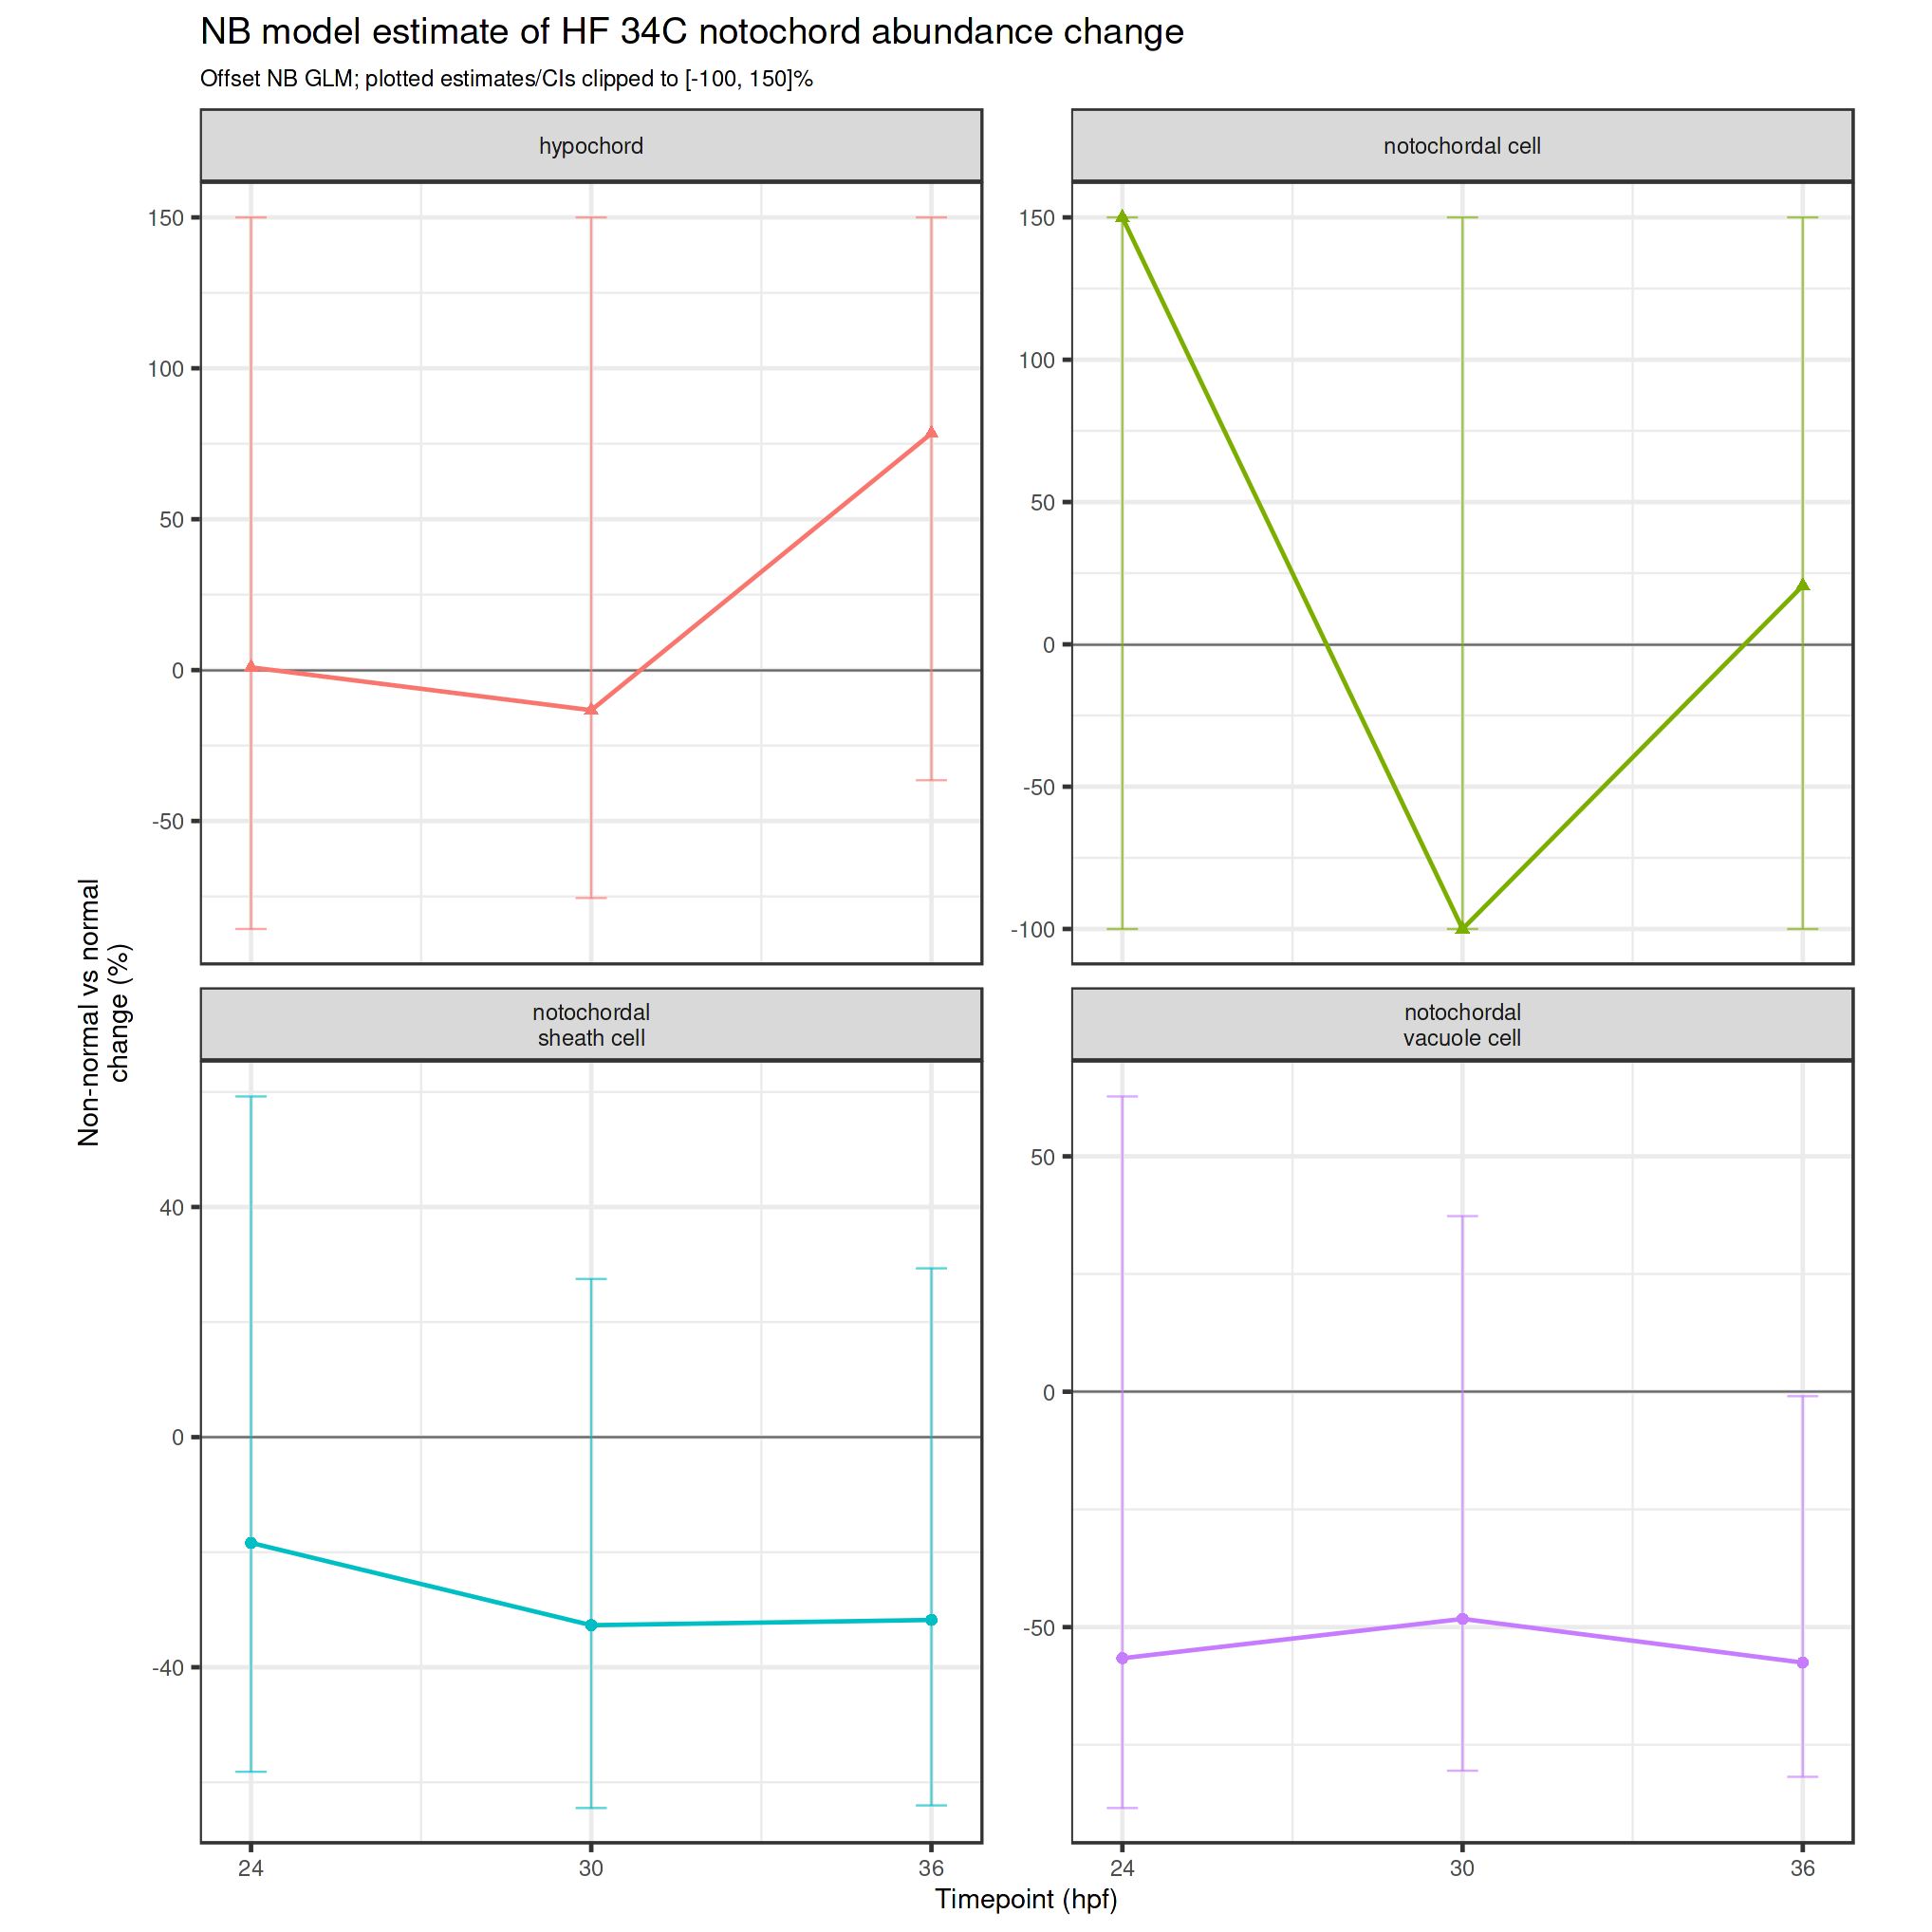

In [15]:
model_effect_plot_limits <- c(-100, 150)
nb_model_plot_width <- 12 * plot_dimension_scale
nb_model_plot_height <- 12 * plot_dimension_scale
options(repr.plot.width = nb_model_plot_width, repr.plot.height = nb_model_plot_height)

nb_model_plot_df <- nb_model_results %>%
  filter(model_converged, group_type == "mapped cell type") %>%
  mutate(
    signed_percent_change_plot = pmin(pmax(signed_percent_change, model_effect_plot_limits[[1]]), model_effect_plot_limits[[2]]),
    ci_lower_percent_plot = pmin(pmax(ci_lower_percent, model_effect_plot_limits[[1]]), model_effect_plot_limits[[2]]),
    ci_upper_percent_plot = pmin(pmax(ci_upper_percent, model_effect_plot_limits[[1]]), model_effect_plot_limits[[2]]),
    estimate_clipped = signed_percent_change != signed_percent_change_plot |
      ci_lower_percent != ci_lower_percent_plot |
      ci_upper_percent != ci_upper_percent_plot
  )

p_nb_model <- ggplot(
  nb_model_plot_df,
  aes(x = hpf, y = signed_percent_change_plot, color = standardized_cell_group, group = standardized_cell_group)
) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "grey40") +
  geom_errorbar(aes(ymin = ci_lower_percent_plot, ymax = ci_upper_percent_plot), width = 0.55, alpha = 0.65) +
  geom_line(linewidth = 1.0) +
  geom_point(aes(shape = estimate_clipped), size = 3) +
  scale_shape_manual(values = c(`FALSE` = 16, `TRUE` = 17), guide = "none") +
  scale_x_continuous(breaks = sort(unique(nb_model_results$hpf))) +
  facet_wrap(
    ~ standardized_cell_group,
    scales = "free_y",
    labeller = labeller(standardized_cell_group = label_wrap_gen(width = 18))
  ) +
  labs(
    title = "NB model estimate of HF 34C notochord abundance change",
    subtitle = "Offset NB GLM; plotted estimates/CIs clipped to [-100, 150]% ",
    x = "Timepoint (hpf)",
    y = "Non-normal vs normal\nchange (%)",
    color = "Cell group"
  ) +
  theme(
    legend.position = "none",
    axis.text = element_text(size = 14),
    axis.title = element_text(size = 17),
    strip.text = element_text(size = 14, lineheight = 0.95),
    panel.spacing = grid::unit(1.0, "lines"),
    aspect.ratio = 1,
    plot.title = element_text(size = 23),
    plot.subtitle = element_text(size = 14)
  )

p_nb_model

ggsave(file.path(out_dir, "hf_34c_notochord_nb_model_effects.png"), p_nb_model, width = nb_model_plot_width, height = nb_model_plot_height, dpi = 300)
ggsave(file.path(out_dir, "hf_34c_notochord_nb_model_effects.pdf"), p_nb_model, width = nb_model_plot_width, height = nb_model_plot_height)

## Plots

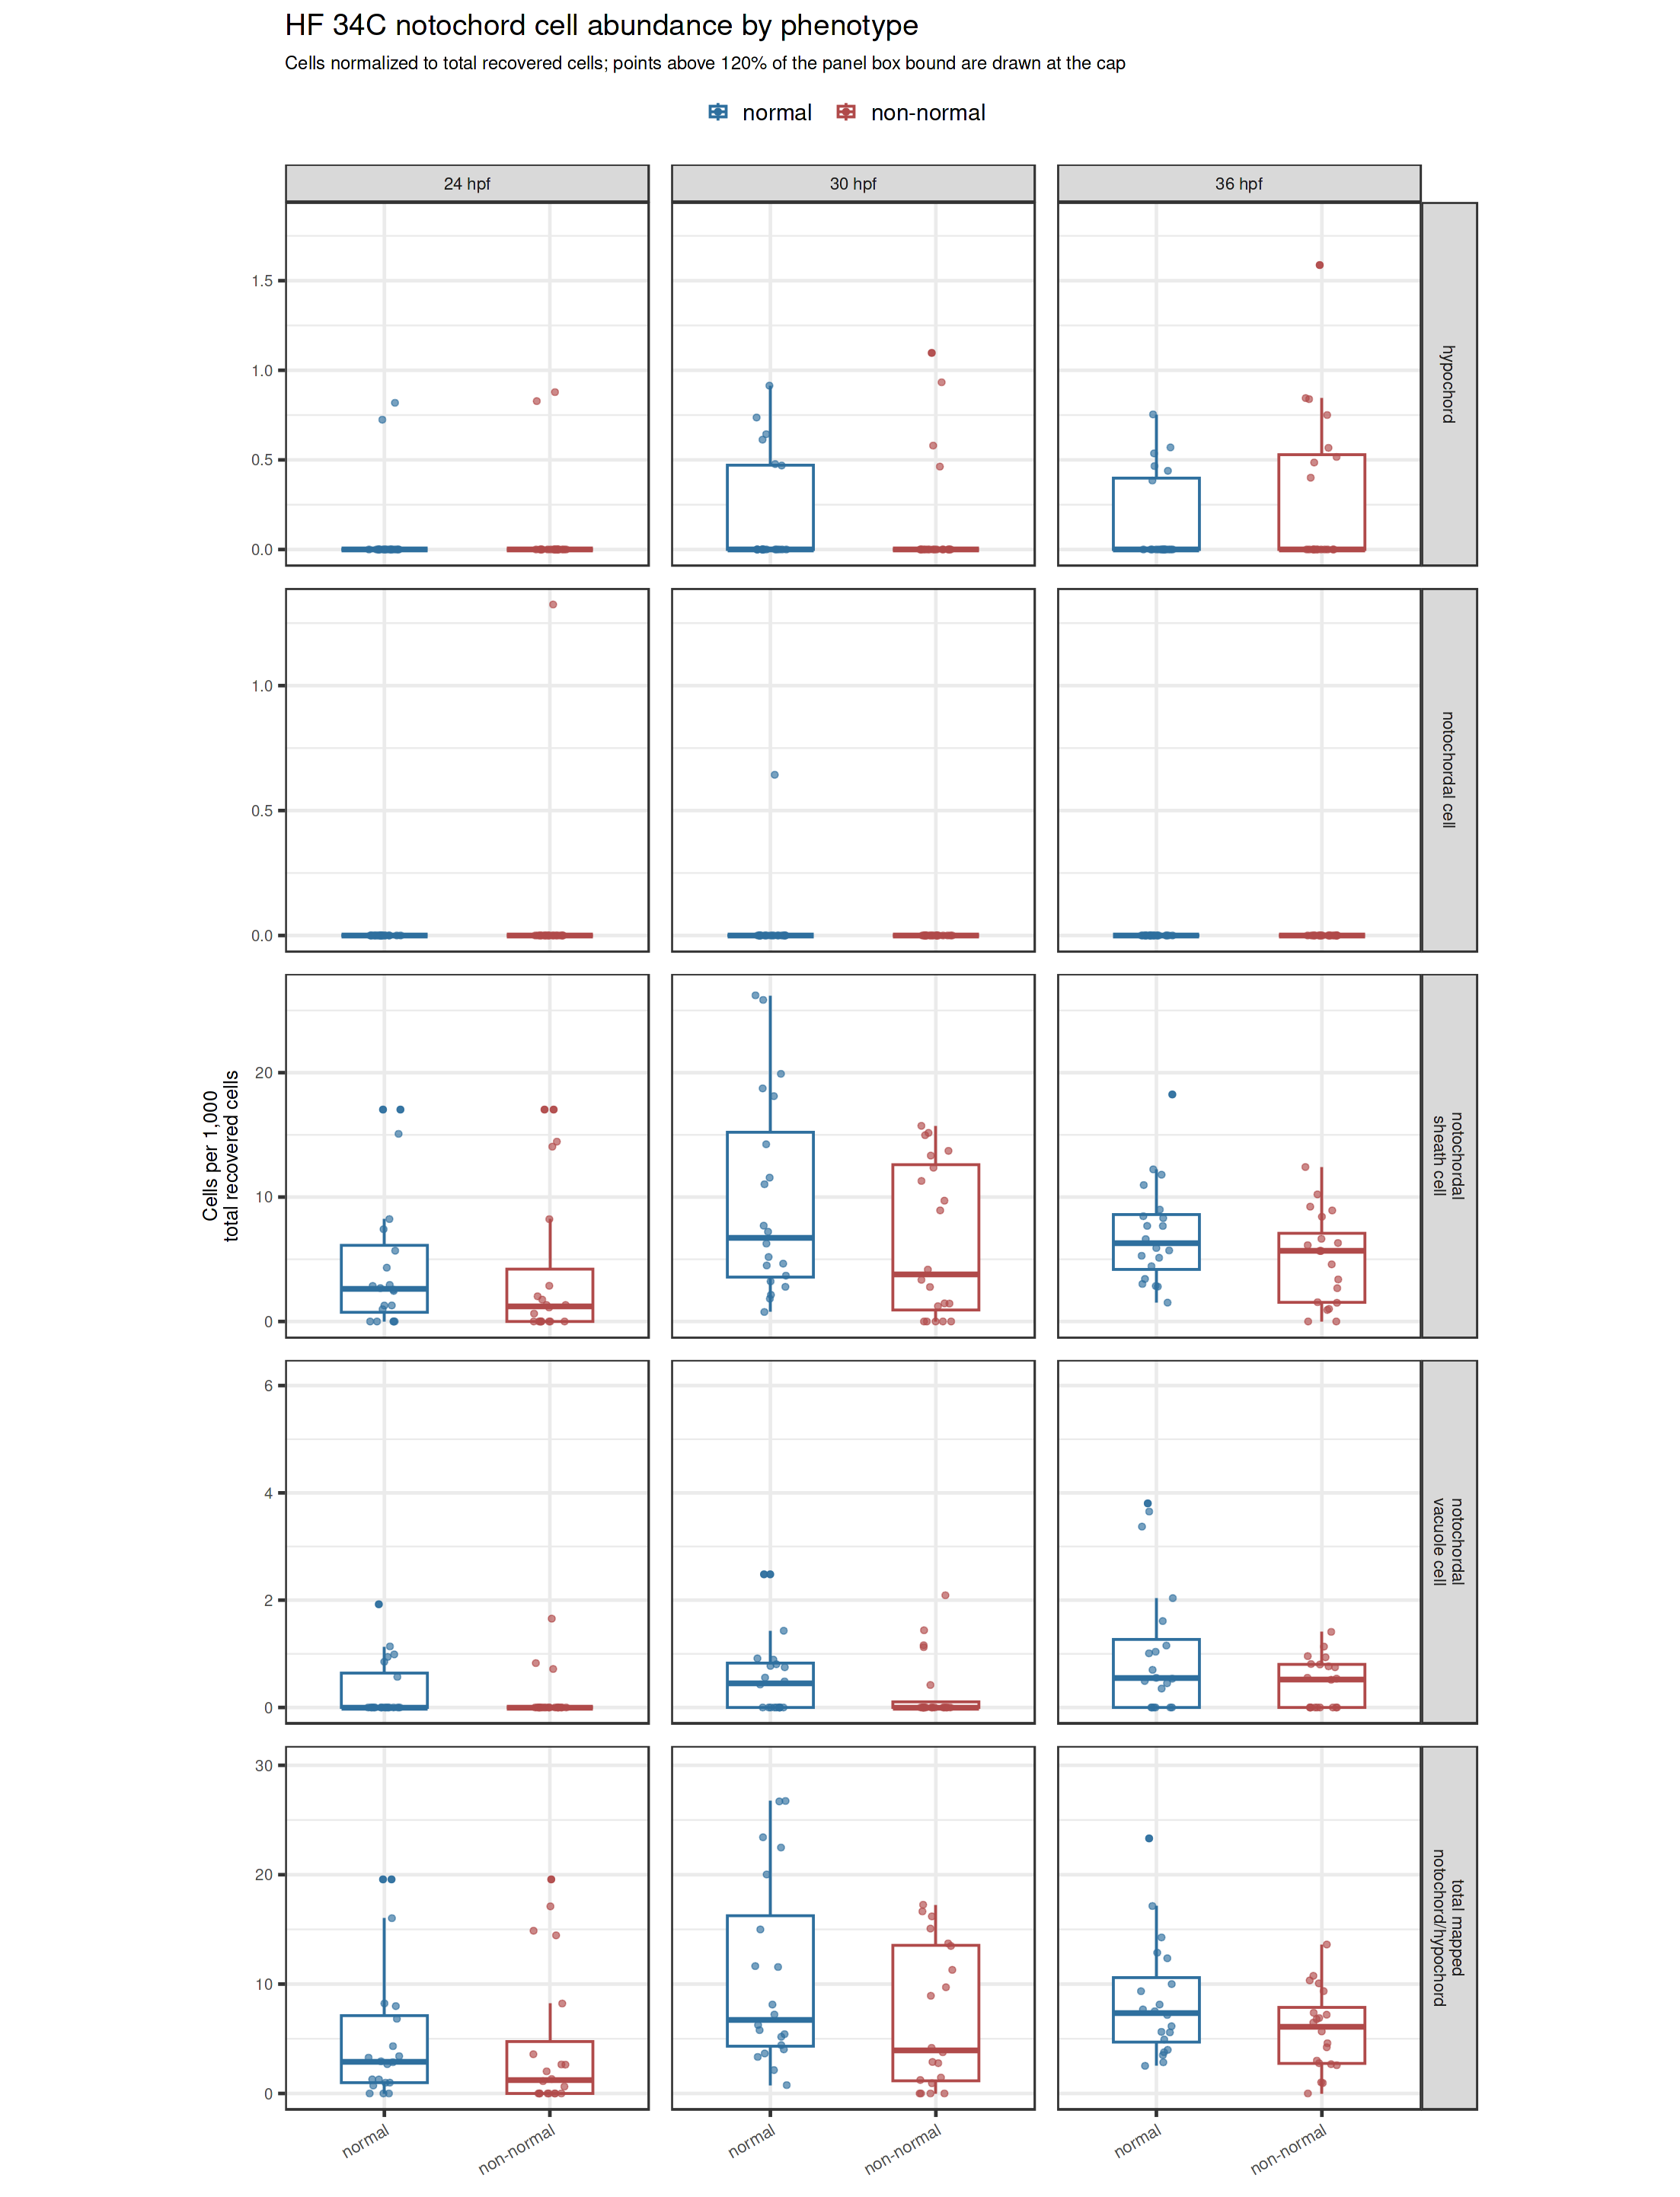

In [16]:
box_upper_bound <- function(x) {
  x <- x[is.finite(x)]
  if (length(x) == 0) return(NA_real_)
  q <- stats::quantile(x, probs = c(0.25, 0.75), na.rm = TRUE, names = FALSE)
  upper <- q[[2]] + 1.5 * (q[[2]] - q[[1]])
  min(max(x, na.rm = TRUE), upper)
}

make_capped_plot_df <- function(data, value_col, cap_multiplier = 1.20) {
  value_col <- deparse(substitute(value_col))

  panel_caps <- data %>%
    group_by(hpf, timepoint_label, standardized_cell_group, phenotype_label) %>%
    summarise(
      box_upper = box_upper_bound(.data[[value_col]]),
      observed_max = max(.data[[value_col]], na.rm = TRUE),
      .groups = "drop"
    ) %>%
    group_by(hpf, timepoint_label, standardized_cell_group) %>%
    summarise(
      y_cap = max(box_upper, na.rm = TRUE) * cap_multiplier,
      observed_max = max(observed_max, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(
      y_cap = if_else(is.finite(y_cap) & y_cap > 0, y_cap, observed_max * 1.05),
      y_cap = if_else(is.finite(y_cap) & y_cap > 0, y_cap, 1)
    )

  data %>%
    left_join(panel_caps, by = c("hpf", "timepoint_label", "standardized_cell_group")) %>%
    mutate(
      plot_value = pmin(.data[[value_col]], y_cap),
      value_capped = .data[[value_col]] > y_cap
    )
}

grid_plot_width <- 13 * plot_dimension_scale
grid_plot_height <- 17 * plot_dimension_scale
options(repr.plot.width = grid_plot_width, repr.plot.height = grid_plot_height)

per_1000_plot_df <- make_capped_plot_df(embryo_counts, cells_per_1000_total, cap_multiplier = 1.20)

p_per_1000 <- ggplot(per_1000_plot_df, aes(x = phenotype_label, color = phenotype_label)) +
  geom_boxplot(aes(y = cells_per_1000_total), outlier.shape = NA, linewidth = 0.8, width = 0.52) +
  geom_point(
    aes(y = plot_value, alpha = value_capped),
    position = position_jitter(width = 0.10, height = 0, seed = 1),
    size = 1.9
  ) +
  facet_grid(
    standardized_cell_group ~ timepoint_label,
    scales = "free_y",
    labeller = labeller(
      standardized_cell_group = label_wrap_gen(width = 18),
      timepoint_label = label_wrap_gen(width = 9)
    )
  ) +
  scale_color_manual(values = c("normal" = "#2E6F9E", "non-normal" = "#B04A4A")) +
  scale_alpha_manual(values = c(`FALSE` = 0.65, `TRUE` = 0.95), guide = "none") +
  labs(
    title = "HF 34C notochord cell abundance by phenotype",
    subtitle = "Cells normalized to total recovered cells; points above 120% of the panel box bound are drawn at the cap",
    x = NULL,
    y = "Cells per 1,000\ntotal recovered cells",
    color = NULL
  ) +
  theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 30, hjust = 1, size = 13),
    axis.text.y = element_text(size = 12),
    axis.title.y = element_text(size = 15),
    strip.text = element_text(size = 13, lineheight = 0.95),
    panel.spacing = grid::unit(1.2, "lines"),
    aspect.ratio = 1,
    plot.title = element_text(size = 23),
    plot.subtitle = element_text(size = 14)
  )

p_per_1000

ggsave(file.path(out_dir, "hf_34c_notochord_cells_per_1000_by_phenotype.png"), p_per_1000, width = grid_plot_width, height = grid_plot_height, dpi = 300)
ggsave(file.path(out_dir, "hf_34c_notochord_cells_per_1000_by_phenotype.pdf"), p_per_1000, width = grid_plot_width, height = grid_plot_height)

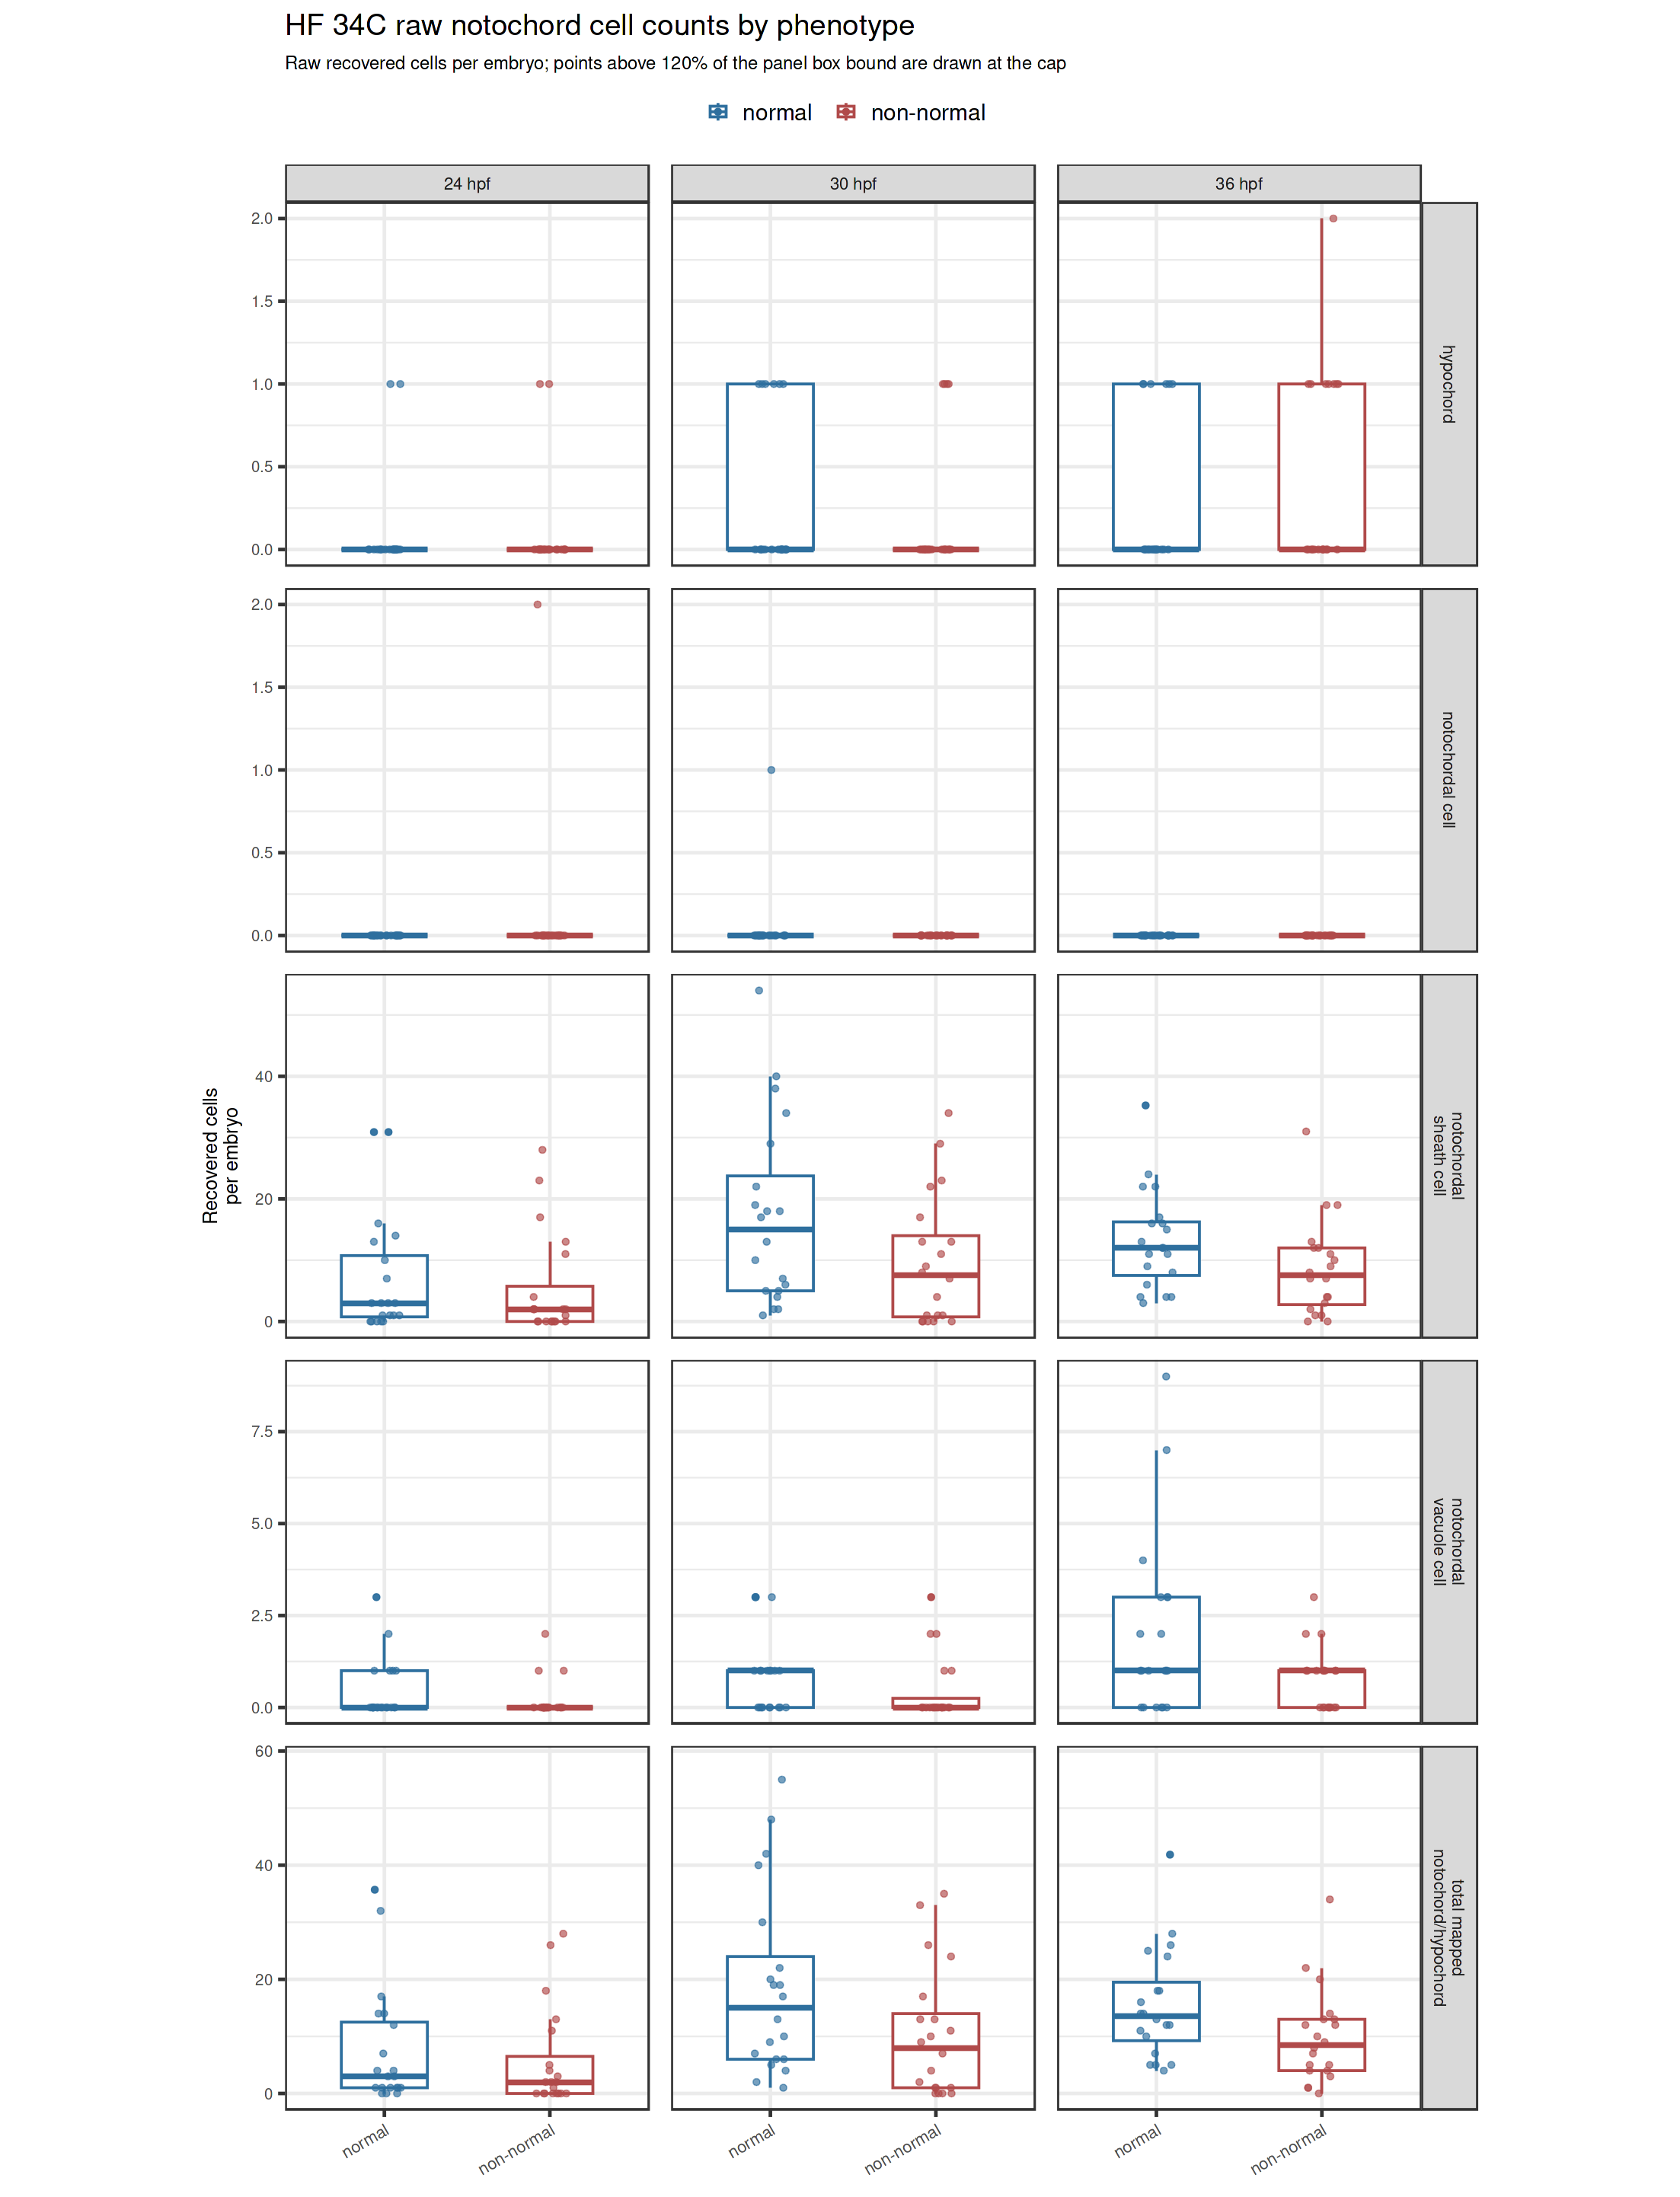

In [17]:
raw_plot_df <- make_capped_plot_df(embryo_counts, cell_count, cap_multiplier = 1.20)
options(repr.plot.width = grid_plot_width, repr.plot.height = grid_plot_height)

p_raw <- ggplot(raw_plot_df, aes(x = phenotype_label, color = phenotype_label)) +
  geom_boxplot(aes(y = cell_count), outlier.shape = NA, linewidth = 0.8, width = 0.52) +
  geom_point(
    aes(y = plot_value, alpha = value_capped),
    position = position_jitter(width = 0.10, height = 0, seed = 2),
    size = 1.9
  ) +
  facet_grid(
    standardized_cell_group ~ timepoint_label,
    scales = "free_y",
    labeller = labeller(
      standardized_cell_group = label_wrap_gen(width = 18),
      timepoint_label = label_wrap_gen(width = 9)
    )
  ) +
  scale_color_manual(values = c("normal" = "#2E6F9E", "non-normal" = "#B04A4A")) +
  scale_alpha_manual(values = c(`FALSE` = 0.65, `TRUE` = 0.95), guide = "none") +
  labs(
    title = "HF 34C raw notochord cell counts by phenotype",
    subtitle = "Raw recovered cells per embryo; points above 120% of the panel box bound are drawn at the cap",
    x = NULL,
    y = "Recovered cells\nper embryo",
    color = NULL
  ) +
  theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 30, hjust = 1, size = 13),
    axis.text.y = element_text(size = 12),
    axis.title.y = element_text(size = 15),
    strip.text = element_text(size = 13, lineheight = 0.95),
    panel.spacing = grid::unit(1.2, "lines"),
    aspect.ratio = 1,
    plot.title = element_text(size = 23),
    plot.subtitle = element_text(size = 14)
  )

p_raw

ggsave(file.path(out_dir, "hf_34c_notochord_raw_counts_by_phenotype.png"), p_raw, width = grid_plot_width, height = grid_plot_height, dpi = 300)
ggsave(file.path(out_dir, "hf_34c_notochord_raw_counts_by_phenotype.pdf"), p_raw, width = grid_plot_width, height = grid_plot_height)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


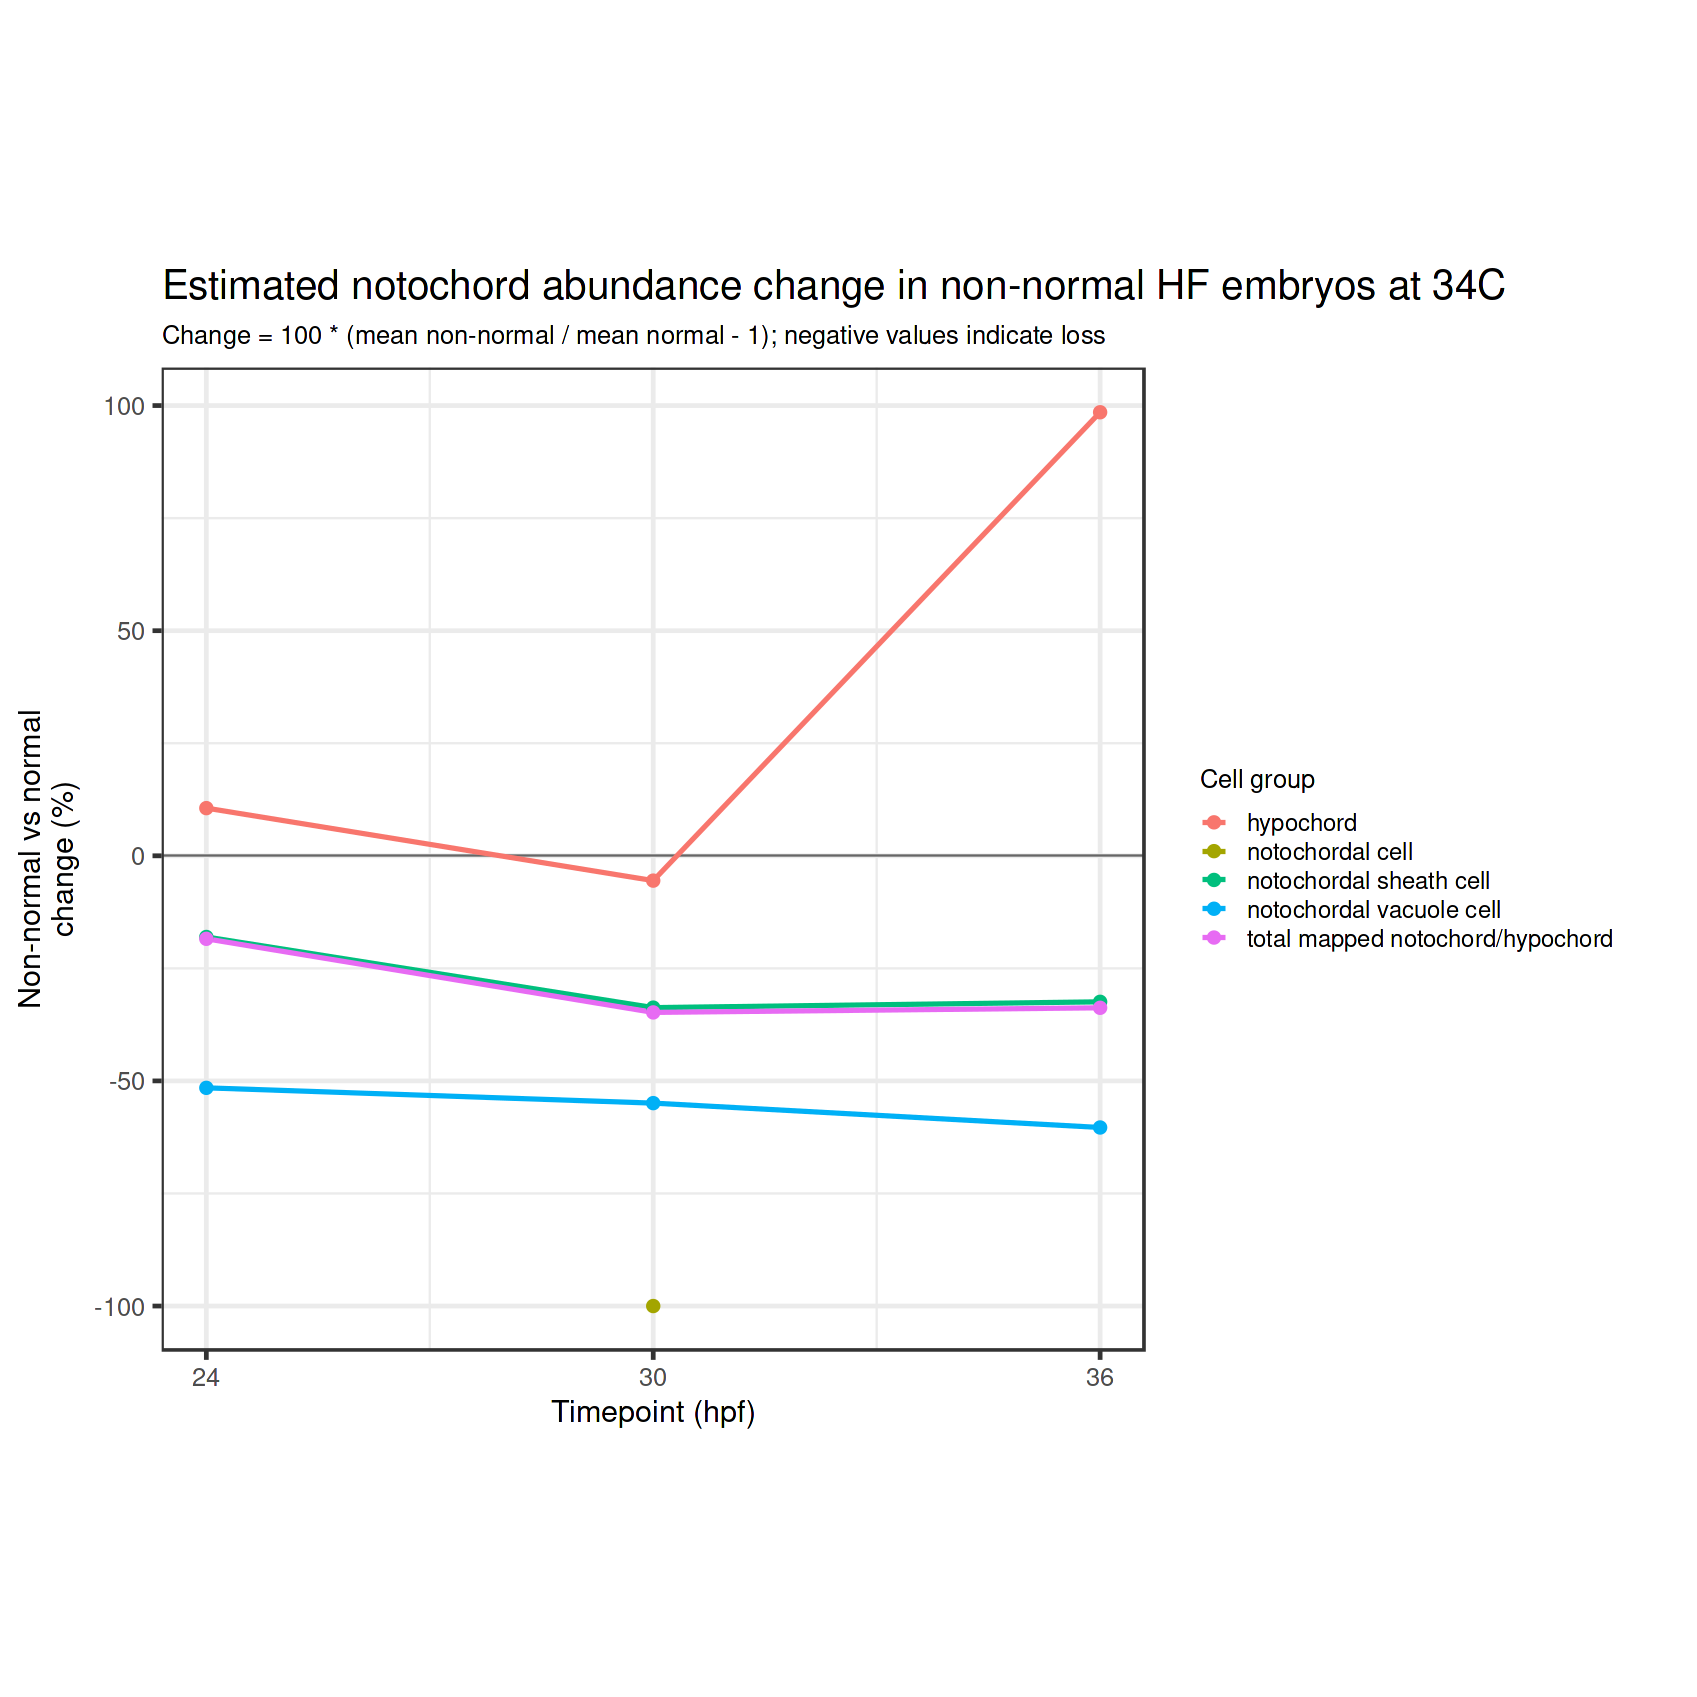

In [18]:
signed_line_plot_width <- 10 * plot_dimension_scale
signed_line_plot_height <- 10 * plot_dimension_scale
options(repr.plot.width = signed_line_plot_width, repr.plot.height = signed_line_plot_height)

p_loss <- loss_summary %>%
  mutate(signed_change_percent = -100 * fractional_loss_mean_per_1000) %>%
  ggplot(aes(x = hpf, y = signed_change_percent, color = standardized_cell_group, group = standardized_cell_group)) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "grey40") +
  geom_line(linewidth = 1.1) +
  geom_point(size = 3) +
  scale_x_continuous(breaks = sort(unique(loss_summary$hpf))) +
  labs(
    title = "Estimated notochord abundance change in non-normal HF embryos at 34C",
    subtitle = "Change = 100 * (mean non-normal / mean normal - 1); negative values indicate loss",
    x = "Timepoint (hpf)",
    y = "Non-normal vs normal\nchange (%)",
    color = "Cell group"
  ) +
  theme(
    legend.position = "right",
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 18),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 15),
    aspect.ratio = 1,
    plot.title = element_text(size = 24),
    plot.subtitle = element_text(size = 15)
  )

p_loss

ggsave(file.path(out_dir, "hf_34c_notochord_fractional_loss_by_timepoint.png"), p_loss, width = signed_line_plot_width, height = signed_line_plot_height, dpi = 300)
ggsave(file.path(out_dir, "hf_34c_notochord_fractional_loss_by_timepoint.pdf"), p_loss, width = signed_line_plot_width, height = signed_line_plot_height)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”


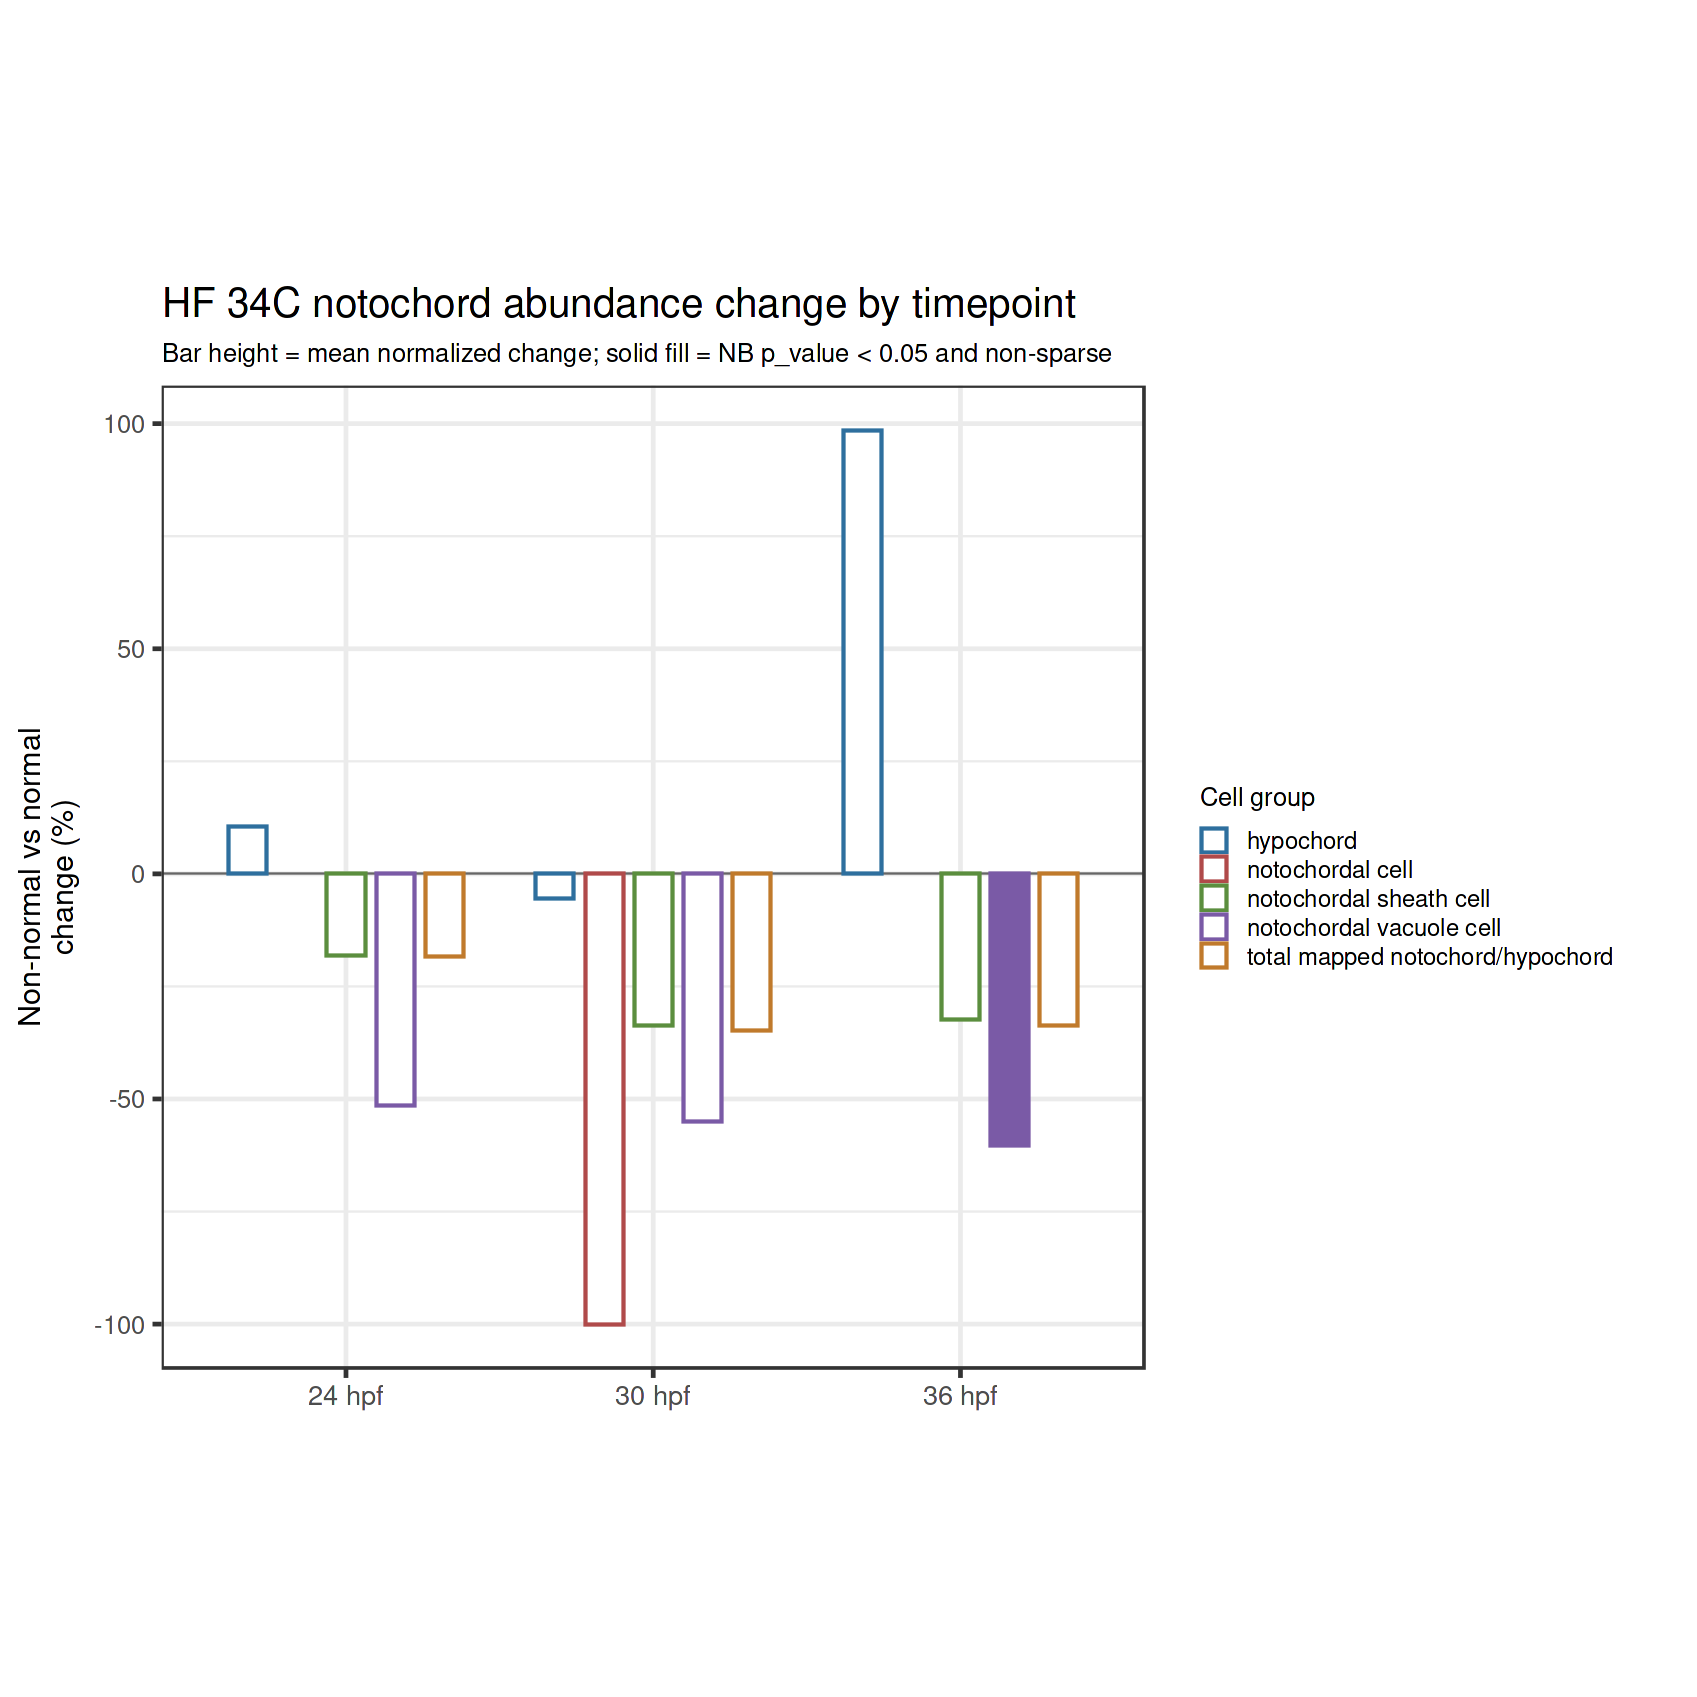

In [19]:
signed_bar_plot_width <- 10 * plot_dimension_scale
signed_bar_plot_height <- 10 * plot_dimension_scale
options(repr.plot.width = signed_bar_plot_width, repr.plot.height = signed_bar_plot_height)

if (!bar_significance_column %in% c("p_value", "wald_p_value", "bh_q_value")) {
  stop("bar_significance_column must be one of: p_value, wald_p_value, bh_q_value")
}

bar_significance_df <- nb_model_results %>%
  mutate(
    standardized_cell_group = as.character(standardized_cell_group),
    significance_value = .data[[bar_significance_column]],
    significant_by_nb = model_converged &
      !is.na(significance_value) &
      significance_value < nb_significance_alpha,
    significant_for_fill = if (solid_fill_requires_non_sparse) {
      significant_by_nb & !sparse_timepoint
    } else {
      significant_by_nb
    }
  ) %>%
  dplyr::select(
    standardized_cell_group,
    hpf,
    nb_p_value = p_value,
    nb_wald_p_value = wald_p_value,
    nb_bh_q_value = bh_q_value,
    nb_significance_value = significance_value,
    sparse_timepoint,
    significant_by_nb,
    significant_for_fill
  )

bar_plot_df <- loss_summary %>%
  mutate(
    standardized_cell_group = as.character(standardized_cell_group),
    signed_change_percent = -100 * fractional_loss_mean_per_1000
  ) %>%
  left_join(bar_significance_df, by = c("standardized_cell_group", "hpf")) %>%
  mutate(
    significant_for_fill = coalesce(significant_for_fill, FALSE),
    standardized_cell_group = factor(standardized_cell_group, levels = unique(as.character(loss_summary$standardized_cell_group))),
    bar_fill_group = if_else(significant_for_fill, as.character(standardized_cell_group), "not significant")
  )

bar_groups <- levels(droplevels(bar_plot_df$standardized_cell_group))
bar_palette <- c("#2E6F9E", "#B04A4A", "#5B8E3E", "#7A5AA6", "#C07A2C", "#4D4D4D", "#1B9E77", "#D95F02")
bar_palette <- setNames(rep(bar_palette, length.out = length(bar_groups)), bar_groups)
bar_fill_palette <- c(bar_palette, "not significant" = "white")
bar_position <- position_dodge(width = 0.8)

p_loss_bars <- ggplot(
  bar_plot_df,
  aes(x = timepoint_label, y = signed_change_percent, group = standardized_cell_group)
) +
  geom_hline(yintercept = 0, linewidth = 0.5, color = "grey40") +
  geom_col(
    aes(color = standardized_cell_group, fill = bar_fill_group),
    position = bar_position,
    width = 0.62,
    linewidth = 0.9
  ) +
  scale_color_manual(values = bar_palette, drop = FALSE) +
  scale_fill_manual(values = bar_fill_palette, drop = FALSE) +
  guides(
    fill = "none",
    color = guide_legend(override.aes = list(fill = "white"))
  ) +
  labs(
    title = "HF 34C notochord abundance change by timepoint",
    subtitle = sprintf(
      "Bar height = mean normalized change; solid fill = NB %s < %.2g%s",
      bar_significance_column,
      nb_significance_alpha,
      ifelse(solid_fill_requires_non_sparse, " and non-sparse", "")
    ),
    x = NULL,
    y = "Non-normal vs normal\nchange (%)",
    color = "Cell group"
  ) +
  theme(
    legend.position = "right",
    axis.text.x = element_text(size = 16),
    axis.text.y = element_text(size = 15),
    axis.title = element_text(size = 18),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 15),
    aspect.ratio = 1,
    plot.title = element_text(size = 24),
    plot.subtitle = element_text(size = 15)
  )

p_loss_bars

ggsave(file.path(out_dir, "hf_34c_notochord_fractional_loss_bars.png"), p_loss_bars, width = signed_bar_plot_width, height = signed_bar_plot_height, dpi = 300)
ggsave(file.path(out_dir, "hf_34c_notochord_fractional_loss_bars.pdf"), p_loss_bars, width = signed_bar_plot_width, height = signed_bar_plot_height)

## Things to double-check

- The label table currently contributes only 24, 30, and 36 hpf embryos at 34C.
- I treat `severe` as the non-normal group. If you add `mild`, `moderate`, or other labels, they will also fall into non-normal unless you split them explicitly.
- The key assumes early notochord and early notochord progenitor map to `notochordal cell`; all sheath labels map to `notochordal sheath cell`; early/late vacuolated notochord maps to `notochordal vacuole cell`; suspected doublets are dropped.
- The primary loss estimate is normalized to total recovered cells per embryo, not to total notochord cells.
- Review `join_diagnostics` before interpreting results. Every labeled 34C embryo should match a CDS embryo, with matching hpf/temp.
- The NB model uses nominal p-values for the primary table and also reports BH q-values across modeled cell groups within each timepoint.
- Loss/change plots now use the signed convention: negative values mean fewer cells in non-normal embryos.
- Final bar plot uses NB Wald p-values by default: solid fill means `bar_significance_column < nb_significance_alpha`; outline-only bars are not significant under that setting.
